# US Firm Characteristics - Strategy Analysis

This notebook converts the backtest registry for the US
firm-characteristics case study into a per-case-study strategy
assessment. Metrics are reported with a block-bootstrap
confidence interval, every comparison goes through
`backtest_paired_metrics`, and the holdout closure uses paired rather
than point-difference reasoning. Cross-case-study comparison is reserved
for Chapter 20.

**Learning objectives**

- Read uncertainty-aware backtest metrics (Sharpe with CI, PSR, DSR) from
  the registry rather than transcribing point estimates.
- Resolve the single holdout evaluation from the selected validation run's
  complete strategy specification rather than selecting on holdout performance.
- Quantify implementation friction with a micro-cap-realistic extended
  cost grid driven by the illiquidity profile of selected stocks.
- Distinguish a decay whose CI includes zero because the effect is absent
  from one whose CI includes zero because a one-year holdout is short.

**Book reference**: Chapter 20, §20.1 (the §9 handoff feeds Ch20's
cross-case-study aggregation).

**Prerequisites**: case-study pipeline through
[`16_holdout_backtest`](16_holdout_backtest.ipynb); the registry
(`case_studies/us_firm_characteristics/run_log/registry.db`).

**Scope**: no training or re-backtesting. The case-study pipeline registers
the derived paired-metrics rows before this notebook runs, after which the
analysis is registry-read only.

In [1]:
"""US Firm Characteristics - Strategy Analysis."""

import datetime as _dt
import json
import sqlite3
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch  # ml4t.diagnostic loads cudart; torch must import first
import yaml
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore")

In [2]:
from ml4t.diagnostic.evaluation import PortfolioAnalysis
from ml4t.diagnostic.integration import (
    BacktestReportMetadata,
    generate_tearsheet_from_run_artifacts,
)
from ml4t.diagnostic.visualization.backtest.tail_risk import plot_tail_risk_analysis
from ml4t.diagnostic.visualization.portfolio.drawdown_plots import (
    plot_drawdown_underwater,
)
from ml4t.diagnostic.visualization.portfolio.returns_plots import (
    plot_annual_returns_bar,
    plot_cumulative_returns,
    plot_monthly_returns_heatmap,
    plot_returns_distribution,
)
from ml4t.diagnostic.visualization.portfolio.risk_plots import plot_rolling_sharpe

In [3]:
from case_studies.utils.backtest_explorer import BacktestExplorer
from case_studies.utils.benchmark import load_benchmark_metrics, load_benchmark_returns
from case_studies.utils.conformal import CALIBRATION_VERSION
from case_studies.utils.external_benchmarks import (
    align_to_strategy as align_external_benchmark,
)
from case_studies.utils.external_benchmarks import (
    align_to_strategy_monthly as align_external_benchmark_monthly,
)
from case_studies.utils.external_benchmarks import (
    compute_benchmark_diagnostics,
    compute_subperiod_diagnostics,
    load_ff_market_returns,
)

In [4]:
from case_studies.utils.factor_attribution import (
    compute_bootstrap_ci,
    compute_rolling_exposures,
    load_factor_data,
    plot_attribution_waterfall,
    plot_rolling_exposures,
    run_factor_regression,
    run_placebo_benchmark,
)
from case_studies.utils.notebook_contracts import degenerate_prediction_sql
from case_studies.utils.registry import (
    load_backtest_fold_metrics,
    load_backtest_metrics,
    load_paired_metrics,
)
from case_studies.utils.strategy_analysis import (
    ci_status,
    fmt_gate,
    gate1_validation_sharpe_geq_zero,
    gate2_holdout_diff_not_excludes_zero_negatively,
    plot_concentration_curve,
    plot_cost_decay,
    plot_ic_vs_sharpe,
    rank_backtests_on_common_support,
    resolve_canonical_rank1_lineage,
    select_holdout_self_backtest,
)
from utils.paths import display_path, get_case_study_dir, get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, add_message_title, ml4t_diverging

Papermill overrides names in the cell below and nowhere else. Without it the
notebook cannot be run at reduced scale through the same runner production uses,
which is what the pre-production check requires.

In [5]:
CASE_STUDY = "us_firm_characteristics"
SEED = 42

In [6]:
PRIMARY_LABEL = "fwd_ret_1m"  # setup.yaml primary; benchmark series keyed here
PERIODS_PER_YEAR = 12  # monthly cadence
CASE_DIR = get_case_study_dir(CASE_STUDY)
OUTPUT_DIR = get_output_dir(20, CASE_STUDY)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
set_global_seeds(SEED)

with open(CASE_DIR / "config" / "setup.yaml") as f:
    setup = yaml.safe_load(f)

explorer = BacktestExplorer(CASE_STUDY)
print(explorer)

BacktestExplorer('us_firm_characteristics', 1396 runs: allocation=120, cost_sensitivity=22, holdout=2, signal=1252)


Compact formatters keep unavailable registry values explicit in the
reader-facing tables.

In [7]:
def _fmt_ci(point: float | None, lo: float | None, hi: float | None, fmt: str = ".3f") -> str:
    """Compact `point [lo, hi]` formatter with NULL-safety."""
    if point is None:
        return "-"
    p = format(point, fmt)
    if lo is None or hi is None:
        return f"{p} [-, -]"
    return f"{p} [{format(lo, fmt)}, {format(hi, fmt)}]"

In [8]:
def _fmt(val: float | None, fmt: str = ".4f") -> str:
    return "-" if val is None else format(val, fmt)

### The two derived tables this notebook reads

`populate_paired_metrics` is passed this notebook's own `PERIODS_PER_YEAR`. Its default
reads the case study's declaration and resolves to the same 12, so the argument states at
the call site what the function would otherwise resolve on its own. A monthly case study
annualizing at the square root of 252 is the defect this call site carried, and the
explicit value is what makes the cadence visible where the call is read.

`cohort_metrics` holds the selection-bias statistics §3 deflates by, and
`backtest_paired_metrics` holds the bootstrapped comparisons §6 closes the
holdout with. Both are derived from rows the sweep already registered rather
than from any new backtest, and both are computed here when they are absent so
that a registry regenerated by a reader carries them.

The guard matters more than the population. Both computations are idempotent and
reproduce the stored values exactly, but running them still rewrites the registry
file, and the registry is what every published number in this case study is read
from. So they run only when something this notebook needs is absent.

What "absent" means is the closure §6 actually reads: a `val_rank1_self` pair whose
challenger is the holdout backtest this notebook resolves. Neither weaker predicate
works, and both were tried here. A row count is non-empty forever once the validation
pairs are written, so the holdout pairs are never produced. The set of benchmark kinds
present is non-empty forever once ANY holdout has been paired - including a superseded
one - so re-running the holdout on a corrected configuration leaves the table carrying
the previous generation's pairs and §6 raises `Incomplete holdout closure pairs` while
the guard declines to repopulate. That is exactly what happened when this case study's
holdout was regenerated.

In [9]:
from case_studies.utils.cohort_metrics import compute_and_register
from case_studies.utils.paired_metrics import populate_paired_metrics

_db = CASE_DIR / "run_log" / "registry.db"
# Resolved before the guard because the guard asks about this holdout, not about holdouts
# in general. §6 re-resolves it and checks the two agree.
_lineage = resolve_canonical_rank1_lineage(CASE_STUDY)
_expected_holdout = _lineage["holdout_backtest_hash"]
with sqlite3.connect(str(_db)) as _con:
    _tables = {r[0] for r in _con.execute("SELECT name FROM sqlite_master WHERE type='table'")}
    _n_cohorts = (
        _con.execute("SELECT count(*) FROM cohort_metrics").fetchone()[0]
        if "cohort_metrics" in _tables
        else 0
    )
    _n_pairs = (
        _con.execute("SELECT count(*) FROM backtest_paired_metrics").fetchone()[0]
        if "backtest_paired_metrics" in _tables
        else 0
    )
    _kinds_present = (
        {
            row[0]
            for row in _con.execute(
                "SELECT DISTINCT benchmark_kind FROM backtest_paired_metrics "
                "WHERE challenger_hash IS ?",
                (_expected_holdout,),
            )
        }
        if "backtest_paired_metrics" in _tables
        else set()
    )
REQUIRED_PAIR_KINDS = {"val_rank1_self", "equal_weight_holdout_side_artifact"}
if _n_cohorts == 0 or not REQUIRED_PAIR_KINDS.issubset(_kinds_present):
    _cohort_counts = compute_and_register(CASE_STUDY)
    # The lineage is passed rather than re-derived inside. Left to itself the populator
    # ranks the registry on raw Sharpe, which is a fourth selector beside the resolver,
    # this notebook and the costs sweep - and here it picked the retired conformal
    # generation, so the pairs described a carrier the case study does not report.
    _paired_rows = populate_paired_metrics(
        CASE_STUDY, periods_per_year=PERIODS_PER_YEAR, carrier=_lineage
    )
    _n_cohorts = sum(_cohort_counts[k] for k in ("family", "stagelabel", "label"))
    _n_pairs = sum(1 for row in _paired_rows if "skip" not in row)
    print(f"cohort_metrics: {_n_cohorts} rows; backtest_paired_metrics: {_n_pairs} pairs (written)")
else:
    print(
        f"cohort_metrics: {_n_cohorts} rows; backtest_paired_metrics: {_n_pairs} pairs "
        "(already present, nothing written)"
    )

cohort_metrics: 10 rows; backtest_paired_metrics: 7 pairs (already present, nothing written)


## §1 Handoff from model analysis

The strategy phase inherits one selected model from `10_model_analysis.py`
§8. That selection is what §3's deflated Sharpe and §6's holdout closure are
correcting for, so it is stated here rather than treated as settled.

The rule that makes the selection is the pipeline's, not this notebook's: the
highest validation backtest Sharpe across the baseline and allocation stages.
Nothing here overrides it, so which family, configuration and label come
through is read off the resolver below and printed rather than asserted in
prose. IC on the prediction set is computed on continuous model scores against
continuous realized returns.

Only the setup-primary label `fwd_ret_1m` has been backtested. The modelling
stages also fitted the winsorized variant `fwd_ret_1m_win` and the
classification variant `fwd_class_1m`, and their predictions are registered,
but no backtest runs against either - so the strategy phase compares one label
to itself and the variants are outside what this notebook can say anything
about.

The shared resolver applies the common-support contract whenever corrected
conformal rows are present: those candidates start one fold later than the
equal-weight baselines, so ranking them as registered would credit the
difference to the sizing rule when part of it is the shorter window. Validation
chooses the strategy once, and the holdout takes no part in that ranking.

Which sizing rule comes through is read from the selected run's own strategy
spec rather than assumed, because both the equal-weight baseline and the
allocator variants are candidates and either can win.

In [10]:
rank1 = resolve_canonical_rank1_lineage(CASE_STUDY)
TOP_HASH = rank1["val_backtest_hash"]
TOP_PHASH = rank1["val_prediction_hash"]
RANK1_STAGE = rank1["val_stage"]
RANK1_FAMILY = rank1["family"]
RANK1_CONFIG = rank1["config_name"]
RANK1_LABEL = rank1["label"]
COMMON_SUPPORT_SHARPE = rank1["val_sharpe"]
COMMON_SUPPORT_N = rank1["comparison_n_periods"]
COMMON_SUPPORT_START = rank1["comparison_start"]
COMMON_SUPPORT_END = rank1["comparison_end"]

with sqlite3.connect(str(CASE_DIR / "run_log" / "registry.db")) as _con:
    _spec = json.loads(
        _con.execute(
            "SELECT spec_json FROM backtest_runs WHERE backtest_hash = ?", (TOP_HASH,)
        ).fetchone()[0]
    )
RANK1_ALLOCATOR = (_spec.get("strategy", {}).get("allocation") or {}).get("method", "equal_weight")
RANK1_TOP_K = int(_spec["strategy"]["signal"]["top_k"])

Registry metadata anchors the selected run and its prediction-side IC to the
exact validation hashes used downstream.

In [11]:
with sqlite3.connect(str(_db)) as _con:
    _row = _con.execute(
        "SELECT ic_mean_daily, ic_ci_lo, ic_ci_hi, ic_t_hac, ic_p_hac, ic_n_days, "
        "ic_hac_lag, ic_pct_positive "
        "FROM prediction_metrics WHERE prediction_hash = ?",
        (TOP_PHASH,),
    ).fetchone()

Selection-bias statistics come from the family cohort that contains the
selected validation run.

In [12]:
with sqlite3.connect(str(_db)) as _con:
    _cohort_row = _con.execute(
        "SELECT k_variants, dsr_raw, dsr_raw_pvalue, dsr_mp, dsr_mp_pvalue, "
        "dsr_er, dsr_er_pvalue, expected_max_sharpe_raw, "
        "expected_max_sharpe_mp, expected_max_sharpe_er, min_trl_periods_raw, "
        "min_trl_periods_mp, min_trl_periods_er, pbo, pbo_n_combinations, "
        "pbo_n_folds, leader_hash, leader_sharpe "
        "FROM cohort_metrics "
        "WHERE cohort_type='family' AND stage=? AND label=? AND family=?",
        (RANK1_STAGE, RANK1_LABEL, RANK1_FAMILY),
    ).fetchone()

In [13]:
COHORT = (
    {
        "k_variants": _cohort_row[0],
        "dsr_raw": _cohort_row[1],
        "dsr_raw_pvalue": _cohort_row[2],
        "dsr_mp": _cohort_row[3],
        "dsr_mp_pvalue": _cohort_row[4],
        "dsr_er": _cohort_row[5],
        "dsr_er_pvalue": _cohort_row[6],
        "expected_max_sharpe_raw": _cohort_row[7],
        "expected_max_sharpe_mp": _cohort_row[8],
        "expected_max_sharpe_er": _cohort_row[9],
        "min_trl_periods_raw": _cohort_row[10],
        "min_trl_periods_mp": _cohort_row[11],
        "min_trl_periods_er": _cohort_row[12],
        "pbo": _cohort_row[13],
        "pbo_n_combinations": _cohort_row[14],
        "pbo_n_folds": _cohort_row[15],
        "leader_hash": _cohort_row[16],
        "leader_sharpe": _cohort_row[17],
    }
    if _cohort_row is not None
    else None
)

In [14]:
ic_mean, ic_lo, ic_hi, ic_t, ic_p, ic_ndays, ic_lag, ic_pct = _row

print(f"Rank-1: family={RANK1_FAMILY}, config={RANK1_CONFIG}, label={RANK1_LABEL}")
print(f"        prediction_hash={TOP_PHASH}, backtest_hash={TOP_HASH}")
print(
    f"        common-support Sharpe={COMMON_SUPPORT_SHARPE:.4f}, "
    f"n={COMMON_SUPPORT_N}, {COMMON_SUPPORT_START:%Y-%m-%d} to {COMMON_SUPPORT_END:%Y-%m-%d}"
)
print(
    f"        setup-primary label={PRIMARY_LABEL}; comparisons follow rank-1 label={RANK1_LABEL}."
)
print()
print("Per-decision-time IC (validation, continuous score vs continuous returns):")
print(f"  IC = {_fmt_ci(ic_mean, ic_lo, ic_hi, '.4f')}  (HAC, lag={int(ic_lag)})")
print(f"  t_HAC = {ic_t:.3f}, p_HAC = {ic_p:.3e}")
print(f"  n_days = {int(ic_ndays)}, pct_positive = {ic_pct:.1%}")
print(f"  CI status: {ci_status(ic_lo, ic_hi)}")

Rank-1: family=gbm, config=leaves_63_mse, label=fwd_ret_1m
        prediction_hash=63060fdcc823, backtest_hash=2a0b06e45e26
        common-support Sharpe=3.0635, n=99, 2007-10-31 to 2015-12-31
        setup-primary label=fwd_ret_1m; comparisons follow rank-1 label=fwd_ret_1m.

Per-decision-time IC (validation, continuous score vs continuous returns):
  IC = 0.0222 [0.0113, 0.0331]  (HAC, lag=20)
  t_HAC = 4.032, p_HAC = 1.027e-04
  n_days = 110, pct_positive = 61.8%
  CI status: excludes_zero_strong


The holdout run is determined by the selected validation run rather than chosen. The
resolver requires an exact strategy-specification match, the same checkpoint, and a
training run whose own CV declares the holdout fold - so what it returns is
[`15_holdout_predictions`](15_holdout_predictions.ipynb)' refit traded by
[`16_holdout_backtest`](16_holdout_backtest.ipynb), and not a model fitted on the
validation folds and scored here. Any looser rule would let an allocator be picked on
its holdout performance, which is selection wearing the clothes of evaluation.

In [15]:
HO_HASH = select_holdout_self_backtest(CASE_STUDY, TOP_HASH)
if HO_HASH is None:
    raise RuntimeError("No strict-lineage holdout matches the selected validation run.")
if rank1["holdout_backtest_hash"] != HO_HASH:
    raise RuntimeError("Canonical resolver and exact-spec holdout lookup disagree.")

with sqlite3.connect(str(_db)) as _con:
    _holdout_meta = _con.execute(
        "SELECT p.training_hash, t.family, t.config_name, t.label, pm.ic_mean_daily "
        "FROM backtest_runs b "
        "JOIN prediction_sets p ON b.prediction_hash=p.prediction_hash "
        "JOIN training_runs t ON p.training_hash=t.training_hash "
        "JOIN prediction_metrics pm ON p.prediction_hash=pm.prediction_hash "
        "WHERE b.backtest_hash=? AND p.split='holdout'",
        (HO_HASH,),
    ).fetchone()
_HO_TRAINING_HASH, HO_FAMILY, HO_CONFIG, HO_LABEL, HO_IC = _holdout_meta

The publication registry is complete before this analysis runs. The two
derived holdout comparisons must already exist and the validation comparison
must name the frozen validation run exactly.

In [16]:
with sqlite3.connect(str(_db)) as _con:
    _holdout_pairs = _con.execute(
        "SELECT benchmark_kind, benchmark_hash FROM backtest_paired_metrics "
        "WHERE challenger_hash=? AND benchmark_kind IN "
        "('val_rank1_self', 'equal_weight_holdout_side_artifact')",
        (HO_HASH,),
    ).fetchall()
_pair_map = {kind: benchmark_hash for kind, benchmark_hash in _holdout_pairs}
if set(_pair_map) != {"val_rank1_self", "equal_weight_holdout_side_artifact"}:
    raise RuntimeError(f"Incomplete holdout closure pairs: {_pair_map}")
if _pair_map["val_rank1_self"] != TOP_HASH:
    raise RuntimeError("Holdout decay is not paired against the frozen validation run.")

In [17]:
print(
    f"Strict-lineage holdout: {HO_FAMILY}/{HO_CONFIG}, label={HO_LABEL}, "
    f"backtest_hash={HO_HASH}, IC={HO_IC:.4f}"
)

Strict-lineage holdout: gbm/leaves_63_mse, label=fwd_ret_1m, backtest_hash=d8bc220e6fa5, IC=0.0395


The IC table above reads as a continuous-score-vs-continuous-return
signal: HAC-adjusted CI status indicates whether the prediction edge
is `excludes_zero_strong` on the positive side. The strategy-side
translation of the prediction-stage IC depends on how concentrated the
book is: the same IC spread over a handful of names and over the whole
cross section produce different Sharpes. §3 reports the selection-adjusted
Sharpe under the sweep's k-variants search.

**Kill conditions** are not encoded in `setup.yaml` for this CS. The
notebook evaluates two universal gates in §9: (i) the validation Sharpe
CI lower bound ≥ 0, and (ii) the holdout strategy-vs-EW paired CI does
not exclude zero on the negative side. Both are reported as
pass, partial or fail, and neither is turned into a recommendation.

## §2 Search context, family comparison, and lineage waterfall

The equal-weight baseline covers the full family x config x label grid. The
search-context table below summarizes that distribution; the family-level
breakdown then locates the selected run within it, which is what makes the size
of the search visible rather than only its maximum.

In [18]:
ctx = explorer.search_context("signal")
search_table = pl.DataFrame(
    [
        {"metric": "Total baseline backtests", "value": f"{ctx['total']:,}"},
        {"metric": "Mean Sharpe", "value": f"{ctx['mean_sharpe']:.3f}"},
        {"metric": "Median Sharpe", "value": f"{ctx['median_sharpe']:.3f}"},
        {"metric": "P90 Sharpe", "value": f"{ctx['p90_sharpe']:.3f}"},
        {"metric": "% positive Sharpe", "value": f"{ctx['pct_positive']:.1f}%"},
        {"metric": "Top-by-Sharpe in this sweep", "value": f"{ctx['champion_sharpe']:.3f}"},
        {"metric": "Top-by-Sharpe percentile", "value": f"{ctx['champion_percentile']:.1f}%"},
    ]
)
print("Equal-weight baseline search context:")
print(search_table)

Equal-weight baseline search context:
shape: (7, 2)
┌─────────────────────────────┬────────┐
│ metric                      ┆ value  │
│ ---                         ┆ ---    │
│ str                         ┆ str    │
╞═════════════════════════════╪════════╡
│ Total baseline backtests    ┆ 1,252  │
│ Mean Sharpe                 ┆ 1.145  │
│ Median Sharpe               ┆ 1.119  │
│ P90 Sharpe                  ┆ 1.962  │
│ % positive Sharpe           ┆ 99.6%  │
│ Top-by-Sharpe in this sweep ┆ 2.863  │
│ Top-by-Sharpe percentile    ┆ 100.0% │
└─────────────────────────────┴────────┘


In [19]:
with sqlite3.connect(str(_db)) as _con:
    _famdf = pl.DataFrame(
        _con.execute(
            """
            SELECT
                t.family,
                bm.sharpe,
                bm.max_drawdown,
                bm.sharpe_ci95_lo,
                bm.sharpe_ci95_hi
            FROM backtest_metrics bm
            JOIN backtest_runs b ON bm.backtest_hash = b.backtest_hash
            JOIN prediction_sets p ON b.prediction_hash = p.prediction_hash
            JOIN training_runs t  ON p.training_hash = t.training_hash
            WHERE b.stage = 'signal'
              AND p.split = 'validation'
              AND (bm.num_trades IS NULL OR bm.num_trades > 0)
            """
        ).fetchall(),
        schema=["family", "sharpe", "max_drawdown", "sharpe_ci95_lo", "sharpe_ci95_hi"],
        orient="row",
    )

# The statistics are taken over the runs that stayed solvent, and the rest are counted
# beside them - the same treatment `11_backtest` gives its family table, so the two agree
# rather than reporting different medians for the same family. A run whose equity reached
# zero has no capital left to earn a return, so its Sharpe is arithmetic on nothing and
# would move a median it has no claim on; dropping those runs without counting them would
# instead rank a family by its survivors. Runs with no recorded drawdown are counted apart,
# because a failure that was never measured is not a bankruptcy. The rows are not filtered
# on Sharpe: a bankrupt run can carry a null one, and dropping it in SQL would remove it
# before `insolvent` counts it.
_solvent = pl.col("max_drawdown") > -1.0
_solvent_mask = _solvent.fill_null(False)
family_summary = (
    _famdf.group_by("family")
    .agg(
        n=_solvent.sum(),
        insolvent=(pl.col("max_drawdown") <= -1.0).sum(),
        unknown=pl.col("max_drawdown").is_null().sum(),
        sharpe_median=pl.col("sharpe").filter(_solvent_mask).median(),
        sharpe_q25=pl.col("sharpe").filter(_solvent_mask).quantile(0.25),
        sharpe_q75=pl.col("sharpe").filter(_solvent_mask).quantile(0.75),
        sharpe_max=pl.col("sharpe").filter(_solvent_mask).max(),
        pct_positive=(pl.col("sharpe").filter(_solvent_mask) > 0).mean() * 100,
    )
    .sort("sharpe_median", descending=True, nulls_last=True)
)
print("Family-level equal-weight baseline Sharpe summary, over the solvent runs:")
# Nine columns is past the default width, and the column polars elides first is the median -
# the one the text above asks the reader to compare against the maximum.
with pl.Config(tbl_cols=-1, tbl_width_chars=160):
    print(family_summary)

Family-level equal-weight baseline Sharpe summary, over the solvent runs:
shape: (4, 9)
┌────────────────┬─────┬───────────┬─────────┬───────────────┬────────────┬────────────┬────────────┬──────────────┐
│ family         ┆ n   ┆ insolvent ┆ unknown ┆ sharpe_median ┆ sharpe_q25 ┆ sharpe_q75 ┆ sharpe_max ┆ pct_positive │
│ ---            ┆ --- ┆ ---       ┆ ---     ┆ ---           ┆ ---        ┆ ---        ┆ ---        ┆ ---          │
│ str            ┆ u32 ┆ u32       ┆ u32     ┆ f64           ┆ f64        ┆ f64        ┆ f64        ┆ f64          │
╞════════════════╪═════╪═══════════╪═════════╪═══════════════╪════════════╪════════════╪════════════╪══════════════╡
│ gbm            ┆ 589 ┆ 11        ┆ 0       ┆ 1.600935      ┆ 1.360385   ┆ 1.9113     ┆ 2.863285   ┆ 100.0        │
│ tabular_dl     ┆ 279 ┆ 9         ┆ 0       ┆ 0.830468      ┆ 0.671973   ┆ 1.13589    ┆ 1.741606   ┆ 100.0        │
│ linear         ┆ 112 ┆ 0         ┆ 0       ┆ 0.570449      ┆ 0.392841   ┆ 0.726461   ┆ 0.84

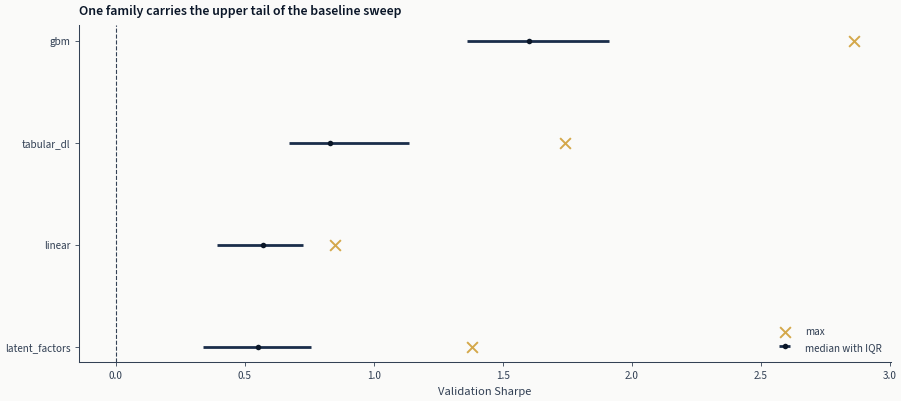

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))
fams = family_summary["family"].to_list()
y = np.arange(len(fams))
medians = family_summary["sharpe_median"].to_numpy()
q25 = family_summary["sharpe_q25"].to_numpy()
q75 = family_summary["sharpe_q75"].to_numpy()
maxima = family_summary["sharpe_max"].to_numpy()

ax.errorbar(
    medians,
    y,
    xerr=[medians - q25, q75 - medians],
    fmt="o",
    color=COLORS["blue"],
    ecolor=COLORS["slate"],
    elinewidth=2.0,
    capsize=4,
    label="median with IQR",
)
ax.scatter(maxima, y, marker="x", color=COLORS["amber"], s=60, label="max", zorder=5)
ax.axvline(0, color=COLORS["neutral"], linewidth=0.8, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(fams)
ax.set_xlabel("Validation Sharpe")
add_message_title(ax, "One family carries the upper tail of the baseline sweep")
ax.invert_yaxis()
ax.legend(loc="lower right", frameon=False)
fig.show()

Two statistics answer different questions here. The median says whether a
family's configurations were generally worth trading; the maximum says only
how far its luckiest draw reached, and it rises with the number of
configurations tried whether or not the family has an edge. Where the
families' interquartile ranges overlap, the selected run's margin is a matter of
where it sat within its own family's spread rather than of which family it
belongs to.

The lineage records all stages registered against the selected prediction set.
The stage named `signal` in the registry is the equal-weight baseline.

In [21]:
lineage = explorer.champion_lineage(TOP_PHASH)
ci_lo: dict[str, float] = {}
ci_hi: dict[str, float] = {}
for stage_name, info in lineage.items():
    bm = load_backtest_metrics(CASE_STUDY, backtest_hash=info["backtest_hash"])
    if not bm.is_empty():
        row = bm.row(0, named=True)
        ci_lo[stage_name] = row.get("sharpe_ci95_lo")
        ci_hi[stage_name] = row.get("sharpe_ci95_hi")

print("Lineage stages present for the selected prediction:")
for s, info in lineage.items():
    lo, hi = ci_lo.get(s), ci_hi.get(s)
    print(f"  {s}: hash={info['backtest_hash']}, Sharpe={_fmt_ci(info['sharpe'], lo, hi)}")

missing_stages = [s for s in ("allocation", "cost_sensitivity", "risk_overlay") if s not in lineage]
if missing_stages:
    print()
    print(f"Stage transitions not run for this prediction: {missing_stages}")
    print(
        "  (cost_sensitivity and risk_overlay sweeps exist in the registry but "
        "were registered against different prediction_hashes; cross-prediction "
        "stage transitions are Ch20's lane.)"
    )

Lineage stages present for the selected prediction:
  signal: hash=d81732ae8447, Sharpe=2.863 [2.283, 3.537]
  allocation: hash=5721302d3951, Sharpe=3.045 [2.449, 3.753]
  cost_sensitivity: hash=6c8778c8bc6f, Sharpe=3.116 [2.516, 3.835]

Stage transitions not run for this prediction: ['risk_overlay']
  (cost_sensitivity and risk_overlay sweeps exist in the registry but were registered against different prediction_hashes; cross-prediction stage transitions are Ch20's lane.)


The corrected conformal candidates start one fold later than the equal-weight
baselines, so their registry windows are not the same length. Comparing the two
Sharpes as registered would credit the difference to the sizing rule when part
of it is the window. The comparison below recomputes both on the exact
timestamp intersection and raises if the two supports still differ.

The two rows are the strongest candidate under each sizing rule, found by
ranking rather than named, so the comparison reads the same way whichever rule
the selection landed on.

They are drawn from the population the selection rule itself draws from, and they have
to be: both arms are compared against the selected run, and the check below requires
that run to be the strongest under its own sizing rule. A wider pool fails that check
on a run that was never a candidate.

The cost-sensitivity stage is what has to be excluded. Those rows are this same
strategy re-run at each level of the cost grid, so the zero-cost row scores above its
own declared-cost parent, and ranking them here would treat a cost assumption as a
sizing rule. Benchmark families and prediction sets carrying a constant-prediction fold are
excluded for the reason the resolver excludes them: neither is eligible to carry the
case study.

In [22]:
_ELIGIBLE_STAGES = ("signal", "allocation", "risk_overlay", "holdout")
with sqlite3.connect(str(_db)) as _con:
    _sizing_candidates = _con.execute(
        "SELECT b.backtest_hash, "
        "  COALESCE(json_extract(b.spec_json, '$.strategy.allocation.method'),"
        "           'equal_weight') AS allocator, "
        "  json_extract(b.spec_json, '$.strategy.allocation.calibration_version') AS calibration "
        "FROM backtest_runs b "
        "JOIN backtest_metrics bm ON bm.backtest_hash=b.backtest_hash "
        "JOIN prediction_sets p ON p.prediction_hash=b.prediction_hash "
        "JOIN training_runs t ON t.training_hash=p.training_hash "
        f"WHERE b.stage IN ({', '.join('?' * len(_ELIGIBLE_STAGES))}) "
        "AND p.split='validation' AND bm.sharpe IS NOT NULL "
        "AND t.family != 'benchmark'" + degenerate_prediction_sql("p.prediction_hash"),
        _ELIGIBLE_STAGES,
    ).fetchall()

# A superseded conformal calibration is not a candidate; the equal-weight side has no such
# distinction to make. The current contract is read from `CALIBRATION_VERSION` rather than
# written out here: this line named `walk_forward_v2` as the strict rule, and when the
# fleet moved to `walk_forward_v3` the literal stopped matching anything and the notebook
# refused with "no conformal candidate is registered" - which reads as an absent sweep and
# was a stale string.
equal_weight_hashes = [row[0] for row in _sizing_candidates if row[1] == "equal_weight"]
current_conformal_hashes = [
    row[0]
    for row in _sizing_candidates
    if row[1] == "conformal_weighted" and row[2] == CALIBRATION_VERSION
]
if not current_conformal_hashes:
    raise RuntimeError(
        f"No conformal candidate at the current calibration {CALIBRATION_VERSION!r} is "
        "registered. Re-run 12_portfolio_management: the registry's conformal generation "
        "predates the current contract and cannot be executed."
    )
if not equal_weight_hashes:
    raise RuntimeError("No equal-weight baseline candidate is registered.")

sizing_ranking = rank_backtests_on_common_support(
    CASE_STUDY,
    sorted({TOP_HASH, *equal_weight_hashes, *current_conformal_hashes}),
    periods_per_year=PERIODS_PER_YEAR,
)
_allocator_of = {row[0]: row[1] for row in _sizing_candidates}
sizing_ranking = sizing_ranking.with_columns(
    pl.col("backtest_hash").replace_strict(_allocator_of, default="equal_weight").alias("method")
)
BEST_EQUAL_WEIGHT_HASH = sizing_ranking.filter(pl.col("method") == "equal_weight")["backtest_hash"][
    0
]
BEST_CONFORMAL_HASH = sizing_ranking.filter(pl.col("method") == "conformal_weighted")[
    "backtest_hash"
][0]
selection_comparison = sizing_ranking.filter(
    pl.col("backtest_hash").is_in([BEST_EQUAL_WEIGHT_HASH, BEST_CONFORMAL_HASH])
).with_columns(
    pl.when(pl.col("backtest_hash") == TOP_HASH)
    .then(pl.col("method") + pl.lit(" (selected)"))
    .otherwise(pl.col("method"))
    .alias("method")
)
if selection_comparison["n_periods"].n_unique() != 1:
    raise RuntimeError("Selection comparison does not have identical period support.")
if TOP_HASH not in selection_comparison["backtest_hash"].to_list():
    raise RuntimeError(
        "The selected run is not the strongest under its own sizing rule on common support, "
        "which means the registered ranking and the common-support ranking disagree."
    )
print("Strongest candidate under each sizing rule, on common support:")
print(selection_comparison.select("method", "backtest_hash", "sharpe", "n_periods", "start", "end"))

Strongest candidate under each sizing rule, on common support:
shape: (2, 6)
┌─────────────────────┬───────────────┬──────────┬───────────┬───────────────┬─────────────────────┐
│ method              ┆ backtest_hash ┆ sharpe   ┆ n_periods ┆ start         ┆ end                 │
│ ---                 ┆ ---           ┆ ---      ┆ ---       ┆ ---           ┆ ---                 │
│ str                 ┆ str           ┆ f64      ┆ i64       ┆ datetime[μs]  ┆ datetime[μs]        │
╞═════════════════════╪═══════════════╪══════════╪═══════════╪═══════════════╪═════════════════════╡
│ conformal_weighted  ┆ 2a0b06e45e26  ┆ 2.869934 ┆ 109       ┆ 2006-12-29    ┆ 2015-12-31 00:00:00 │
│ (selected)          ┆               ┆          ┆           ┆ 00:00:00      ┆                     │
│ equal_weight        ┆ d81732ae8447  ┆ 2.84078  ┆ 109       ┆ 2006-12-29    ┆ 2015-12-31 00:00:00 │
│                     ┆               ┆          ┆           ┆ 00:00:00      ┆                     │
└─────────────

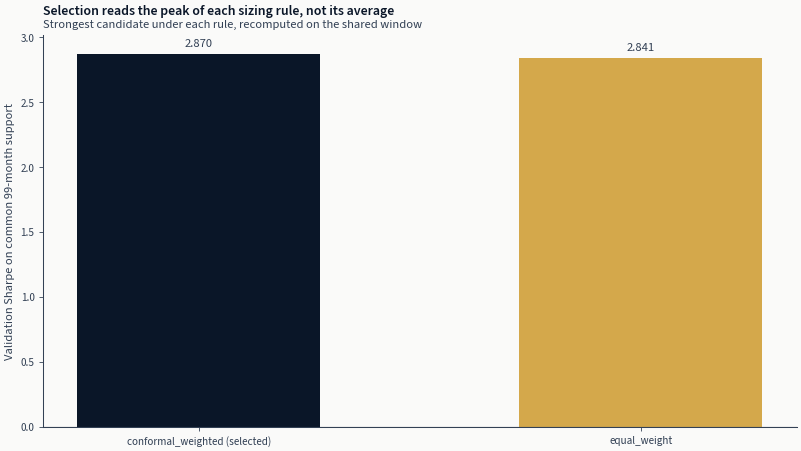

In [23]:
stage_labels = selection_comparison["method"].to_list()
stage_values = selection_comparison["sharpe"].to_numpy()

fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
x = np.arange(len(stage_labels))
bars = ax.bar(
    x,
    stage_values,
    color=[COLORS["blue"], COLORS["amber"]],
    width=0.55,
)
ax.bar_label(bars, labels=[f"{value:.3f}" for value in stage_values], padding=4)
ax.axhline(0, color=COLORS["neutral"], linewidth=0.8)
ax.set_xticks(x, stage_labels)
ax.set_ylabel(f"Validation Sharpe on common {COMMON_SUPPORT_N}-month support")
add_message_title(
    ax,
    "Selection reads the peak of each sizing rule, not its average",
    subtitle="Strongest candidate under each rule, recomputed on the shared window",
)
fig.show()

Two things are true of this comparison and the second does not retract the
first.

The selection rule is the highest validation backtest Sharpe, and it is applied
here without an override. Whichever rule holds the higher bar above is the one
the strategy phase carries, and §3 onward describe that run.

The rule reads one number per candidate, the highest it reached. It does not read
how that rule did across the rest of the grid, and `12_portfolio_management`
measured exactly that. Averaged over the same ten predictions at the same four
concentrations, conformal weighting came out below equal weighting, and eight
of its ten runs at the narrowest concentration ended with negative equity
against equal weighting's two. A rule can own the single highest cell and still
be the weaker rule across the grid, and a selection made on the maximum cannot
tell the two apart.

That is a property of selecting on a maximum rather than a defect in this
case study, and it is the reason §3 reports a deflated Sharpe and §6 closes on
a holdout the selection never saw. Neither correction recovers the average the
selection did not look at; they bound how much of the maximum was the search.

§5 reads the cost-sensitivity sweep as a friction floor across the allocation
cohort rather than as a transition on this lineage.

## §3 Headline performance with uncertainty

The specification is chosen on the common comparison window, and the metric
table then reports the selected run's complete validation record with
block-bootstrap confidence intervals from `backtest_metrics`. Those two windows are not
the same length; the spec block above prints both so the reader can see by
how much.

The bootstrap block length captures serial dependence in the return series and is not
required to match the one-month rebalance step, but it cannot be shorter than it: a
block inside a holding period resamples within one position and understates the
dependence the interval exists to carry. The audit at the end of the cell below
computes that relation rather than asserting it, and stops the notebook if it fails.

In [24]:
full = load_backtest_metrics(CASE_STUDY, backtest_hash=TOP_HASH).row(0, named=True)

top_strategy = _spec["strategy"]
top_signal = top_strategy["signal"]
top_allocation = top_strategy.get("allocation") or {}

spec_block = {
    "case_study": CASE_STUDY,
    "family": RANK1_FAMILY,
    "config_name": RANK1_CONFIG,
    "label": RANK1_LABEL,
    "setup_primary_label": PRIMARY_LABEL,
    "signal_method": top_signal.get("method"),
    "allocator": top_allocation.get("method", "equal_weight"),
    "top_k": top_signal.get("top_k"),
    "rebalance_step": setup["labels"]["rebalance_step"][RANK1_LABEL],
    "cost_assumption": "stage-dependent; §5 reports the cost sensitivity curve",
    "cross_stage_rank1_stage": RANK1_STAGE,
    "selection_sharpe_common_support": COMMON_SUPPORT_SHARPE,
    "selection_window_periods": COMMON_SUPPORT_N,
    "full_validation_sharpe": full["sharpe"],
    "full_validation_periods": int(full["n_periods"]),
    "num_trades": int(full["num_trades"]) if full["num_trades"] is not None else None,
    "avg_turnover": full["avg_turnover"],
    "bootstrap_block_length": int(full["bootstrap_block_length"]),
    "bootstrap_n": int(full["bootstrap_n"]),
}
print("Selected run, validation window:")
for k, v in spec_block.items():
    print(f"  {k}: {v}")

_block = int(full["bootstrap_block_length"])
_rstep = setup["labels"]["rebalance_step"][RANK1_LABEL]
if _block < _rstep:
    raise RuntimeError(
        f"bootstrap block is {_block} months against a {_rstep}-month rebalance step. A "
        "block shorter than the holding period resamples inside it, so the confidence "
        "intervals below would understate the serial dependence they exist to carry."
    )
print(
    f"  dependence audit: bootstrap block={_block} months, rebalance step={_rstep} month, "
    "so the block spans at least one holding period"
)

Selected run, validation window:
  case_study: us_firm_characteristics
  family: gbm
  config_name: leaves_63_mse
  label: fwd_ret_1m
  setup_primary_label: fwd_ret_1m
  signal_method: equal_weight_top_k
  allocator: conformal_weighted
  top_k: 50
  rebalance_step: 1
  cost_assumption: stage-dependent; §5 reports the cost sensitivity curve
  cross_stage_rank1_stage: allocation
  selection_sharpe_common_support: 3.0634684071881852
  selection_window_periods: 99
  full_validation_sharpe: 2.8699339482552833
  full_validation_periods: 109
  num_trades: None
  avg_turnover: 1.101344362766297
  bootstrap_block_length: 6
  bootstrap_n: 1000
  dependence audit: bootstrap block=6 months, rebalance step=1 month, so the block spans at least one holding period


A compact row helper keeps the metric table construction readable.

In [25]:
def _row(metric: str, point: str, lo: str, hi: str, status: str) -> dict:
    return {"metric": metric, "point": point, "ci95_lo": lo, "ci95_hi": hi, "status": status}

In [26]:
metric_specs = [
    ("Sharpe", "sharpe", "sharpe_ci95_lo", "sharpe_ci95_hi"),
    ("Sortino", "sortino", "sortino_ci95_lo", "sortino_ci95_hi"),
    ("Annualized return", "cagr", "ann_return_ci95_lo", "ann_return_ci95_hi"),
    ("Max drawdown", "max_drawdown", "max_dd_ci95_lo", "max_dd_ci95_hi"),
    ("Calmar", "calmar", "calmar_ci95_lo", "calmar_ci95_hi"),
]
headline_rows = [
    _row(name, _fmt(full[point]), _fmt(full[lo]), _fmt(full[hi]), ci_status(full[lo], full[hi]))
    for name, point, lo, hi in metric_specs
]
headline_rows.append(_row("PSR p-value (H0: SR <= 0)", _fmt(full["psr_pvalue"]), "-", "-", "n/a"))

for name, key, p_key, prefix in [
    ("DSR raw", "dsr_raw", "dsr_raw_pvalue", "raw"),
    ("DSR ER (maintainer default)", "dsr_er", "dsr_er_pvalue", "er"),
    ("DSR MP", "dsr_mp", "dsr_mp_pvalue", "mp"),
]:
    point = _fmt(COHORT[key]) if COHORT else "unavailable"
    status = (
        f"{prefix}_p={COHORT[p_key]:.3f}" if COHORT and COHORT[p_key] is not None else "unavailable"
    )
    headline_rows.append(_row(name, point, "-", "-", status))

headline_rows.extend(
    [
        _row("Expected max Sharpe (ER)", _fmt(COHORT["expected_max_sharpe_er"]), "-", "-", "n/a"),
        _row("PBO", _fmt(COHORT["pbo"]), "-", "-", "n/a"),
        _row("k variants (family cohort)", str(int(COHORT["k_variants"])), "-", "-", "n/a"),
    ]
)
headline = pl.DataFrame(headline_rows)
print("Selected strategy, headline metrics with confidence intervals:")
print(headline)

Selected strategy, headline metrics with confidence intervals:
shape: (12, 5)
┌─────────────────────────────┬─────────┬─────────┬─────────┬──────────────────────┐
│ metric                      ┆ point   ┆ ci95_lo ┆ ci95_hi ┆ status               │
│ ---                         ┆ ---     ┆ ---     ┆ ---     ┆ ---                  │
│ str                         ┆ str     ┆ str     ┆ str     ┆ str                  │
╞═════════════════════════════╪═════════╪═════════╪═════════╪══════════════════════╡
│ Sharpe                      ┆ 2.8699  ┆ 2.2982  ┆ 3.5226  ┆ excludes_zero_strong │
│ Sortino                     ┆ 12.4514 ┆ 7.9027  ┆ 20.7589 ┆ excludes_zero_strong │
│ Annualized return           ┆ 0.8330  ┆ 0.5688  ┆ 1.1822  ┆ excludes_zero_strong │
│ Max drawdown                ┆ -0.1010 ┆ -0.1361 ┆ -0.0522 ┆ excludes_zero_strong │
│ Calmar                      ┆ 8.2449  ┆ 4.7960  ┆ 20.0443 ┆ excludes_zero_strong │
│ …                           ┆ …       ┆ …       ┆ …       ┆ …         

Each interval below is drawn from its own lower bound to its own upper bound, with the
point estimate marked on it, rather than as an error bar measured outwards from the
point. The two look identical whenever the interval brackets its estimate and differ
only when it does not - and drawing it this way means that case renders and is visible
instead of raising. A percentile bootstrap is not guaranteed to contain the full-sample
estimate on a skewed series, so an estimate outside its interval is worth reporting and
is not on its own proof of a defect. It was proof of one here: the stored Sortino ratio
and the bootstrap around it were computed from two different downside deviations, and
the printed line below says which metrics sit outside their own bounds.

Every estimate lies inside its own interval.


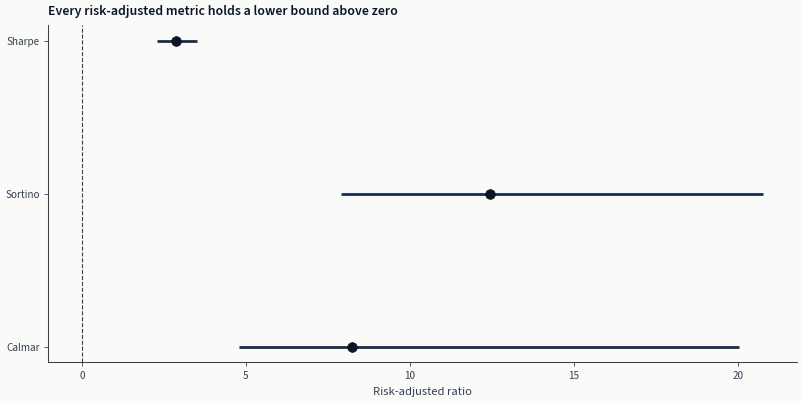

In [27]:
ew_val = load_benchmark_metrics(CASE_STUDY, RANK1_LABEL, period="validation")
forest_metrics = [
    ("Sharpe", full["sharpe"], full["sharpe_ci95_lo"], full["sharpe_ci95_hi"]),
    ("Sortino", full["sortino"], full["sortino_ci95_lo"], full["sortino_ci95_hi"]),
    ("Calmar", full["calmar"], full["calmar_ci95_lo"], full["calmar_ci95_hi"]),
]

inverted = [
    f"{name} ({point:.4f} against [{lo:.4f}, {hi:.4f}])"
    for name, point, lo, hi in forest_metrics
    if not (lo <= point <= hi)
]
print(
    "Every estimate lies inside its own interval."
    if not inverted
    else "Outside its own interval, so the estimate and the interval may not be the same "
    f"quantity measured two ways: {'; '.join(inverted)}"
)

fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(forest_metrics))
points = np.array([m[1] for m in forest_metrics])
los = np.array([m[2] for m in forest_metrics])
his = np.array([m[3] for m in forest_metrics])
ax.hlines(y, los, his, color=COLORS["slate"], linewidth=2.0)
ax.scatter(points, y, color=COLORS["blue"], s=49, zorder=3)
ax.axvline(0, color=COLORS["neutral"], linestyle="--", linewidth=0.8)
ax.set_yticks(y)
ax.set_yticklabels([m[0] for m in forest_metrics])
ax.invert_yaxis()
ax.set_xlabel("Risk-adjusted ratio")
_above_zero = sum(1 for _, _, lo, _ in forest_metrics if lo > 0)
add_message_title(
    ax,
    f"{_above_zero} of {len(forest_metrics)} risk-adjusted metrics hold a lower bound above zero"
    if _above_zero < len(forest_metrics)
    else "Every risk-adjusted metric holds a lower bound above zero",
)
fig.show()

In [28]:
strat_returns_path = CASE_DIR / "run_log" / "backtest" / TOP_HASH / "daily_returns.parquet"
strat_df = (
    pl.read_parquet(strat_returns_path)
    .sort("timestamp")
    .with_columns(pl.col("timestamp").cast(pl.Date).alias("ts"))
    .select(pl.col("ts"), pl.col("daily_return").alias("strategy"))
)

bench_val = (
    load_benchmark_returns(CASE_STUDY, RANK1_LABEL, period="validation")
    .with_columns(pl.col("timestamp").cast(pl.Date).alias("ts"))
    .select(pl.col("ts"), pl.col("ew_return").alias("benchmark"))
)

aligned = strat_df.join(bench_val, on="ts", how="inner").sort("ts")
print(
    f"Validation overlay window: {aligned['ts'].min()} → {aligned['ts'].max()}, n={aligned.height}"
)

Validation overlay window: 2006-12-29 → 2015-12-31, n=109


The validation Sharpe CI is reported above with its `ci_status`
classification. PSR p-value tests H0: Sharpe ≤ 0; the DSR variants
above (raw / MP / ER) report the selection-adjusted equivalent across
the k_variants in the family cohort, with ER the
maintainer-recommended default. PBO is the probability of backtest
overfitting from CSCV on the per-fold Sharpe matrix; §6's val→ho
closure provides the orthogonal out-of-sample check.

The cumulative-return plot shows the validation trajectory against the EW
universe. The y-axis is the cumulative product of monthly returns from the
dollar-neutral long-short structure, so across a decade of months it reaches
end-points that are arithmetic rather than attainable: they assume every
month's gain is reinvested at the same leverage with no capacity limit and
no borrow constraint. The headline annualized-return CI inherits that
assumption. §5 puts the gross profile against implementation friction.

### Second benchmark: Fama-French market

The EW universe is the inside-the-strategy benchmark (untimed
allocation across the same names). The Fama-French market series
(Mkt-RF + RF) is the classical academic external benchmark - what
every cross-sectional anomaly is implicitly compared against. It
matches the strategy's monthly cadence directly. Beta against the
market quantifies whether the long-short construction achieves the
market-neutrality it nominally targets.

In [29]:
ff_m = load_ff_market_returns(
    start=aligned["ts"].min(),
    end=aligned["ts"].max(),
    frequency="monthly",
)
ff_aligned = align_external_benchmark_monthly(
    aligned.select("ts", "strategy"),
    ff_m,
    timestamp_col="ts",
)
ff_diag = compute_benchmark_diagnostics(
    ff_aligned["strategy"].to_numpy(),
    ff_aligned["benchmark_return"].to_numpy(),
    PERIODS_PER_YEAR,
)
ew_diag = compute_benchmark_diagnostics(
    aligned["strategy"].to_numpy(),
    aligned["benchmark"].to_numpy(),
    PERIODS_PER_YEAR,
)

In [30]:
benchmark_table = pl.DataFrame(
    [
        {
            "benchmark": "EW universe (validation)",
            "n_periods": ew_diag["n"],
            "info_ratio": _fmt(ew_diag["info_ratio"], ".3f"),
            "beta": _fmt(ew_diag["beta"], ".3f"),
            "correlation": _fmt(ew_diag["correlation"], ".3f"),
            "tracking_error": _fmt(ew_diag["tracking_error"], ".3f"),
        },
        {
            "benchmark": "FF-market (Mkt-RF + RF, monthly)",
            "n_periods": ff_diag["n"],
            "info_ratio": _fmt(ff_diag["info_ratio"], ".3f"),
            "beta": _fmt(ff_diag["beta"], ".3f"),
            "correlation": _fmt(ff_diag["correlation"], ".3f"),
            "tracking_error": _fmt(ff_diag["tracking_error"], ".3f"),
        },
    ]
)
print("Strategy diagnostics vs benchmarks:")
print(benchmark_table)

Strategy diagnostics vs benchmarks:
shape: (2, 6)
┌─────────────────────────────────┬───────────┬────────────┬────────┬─────────────┬────────────────┐
│ benchmark                       ┆ n_periods ┆ info_ratio ┆ beta   ┆ correlation ┆ tracking_error │
│ ---                             ┆ ---       ┆ ---        ┆ ---    ┆ ---         ┆ ---            │
│ str                             ┆ i64       ┆ str        ┆ str    ┆ str         ┆ str            │
╞═════════════════════════════════╪═══════════╪════════════╪════════╪═════════════╪════════════════╡
│ EW universe (validation)        ┆ 109       ┆ 1.804      ┆ 0.036  ┆ 0.034       ┆ 0.305          │
│ FF-market (Mkt-RF + RF, monthl… ┆ 108       ┆ 1.936      ┆ -0.142 ┆ -0.101      ┆ 0.290          │
└─────────────────────────────────┴───────────┴────────────┴────────┴─────────────┴────────────────┘


### Sub-period decomposition (5-year buckets)

A pooled Sharpe averages over the whole validation window, and an average
hides whether the return arrived steadily or in one stretch. The buckets
below split validation into two roughly five-year windows and place the
holdout beside them. The holdout is resolved through the unique
complete-strategy-spec match within the frozen training lineage, the same
rule §6 uses for the paired closure.

In [31]:
ho_panel = (
    pl.read_parquet(CASE_DIR / "run_log" / "backtest" / HO_HASH / "daily_returns.parquet")
    .sort("timestamp")
    .with_columns(pl.col("timestamp").cast(pl.Date).alias("ts"))
    .select("ts", pl.col("daily_return").alias("strategy"))
)
bench_ho = (
    load_benchmark_returns(CASE_STUDY, RANK1_LABEL, period="holdout")
    .with_columns(pl.col("timestamp").cast(pl.Date).alias("ts"))
    .select("ts", pl.col("ew_return").alias("benchmark"))
)
ho_aligned = (
    ho_panel.join(bench_ho, on="ts", how="inner").sort("ts")
    if ho_panel.height > 0
    else pl.DataFrame()
)

val_buckets = [
    ("2006-2010 (val)", _dt.date(2006, 1, 1), _dt.date(2010, 12, 31)),
    ("2011-2015 (val)", _dt.date(2011, 1, 1), _dt.date(2015, 12, 31)),
]
val_table = compute_subperiod_diagnostics(
    aligned,
    val_buckets,
    periods_per_year=PERIODS_PER_YEAR,
)
ho_table = (
    compute_subperiod_diagnostics(
        ho_aligned,
        [("2016 (ho)", _dt.date(2016, 1, 1), _dt.date(2016, 12, 31))],
        periods_per_year=PERIODS_PER_YEAR,
    )
    if ho_aligned.height > 0
    else pl.DataFrame()
)
subperiod_table = pl.concat([val_table, ho_table]) if ho_table.height > 0 else val_table
print("Sub-period decomposition (validation 5y buckets + holdout):")
print(subperiod_table)

Sub-period decomposition (validation 5y buckets + holdout):
shape: (3, 8)
┌──────────────┬─────┬────────────┬────────────┬──────────┬─────────────┬────────────┬─────────────┐
│ bucket       ┆ n   ┆ cum_return ┆ ann_return ┆ sharpe   ┆ max_drawdow ┆ beta_vs_bm ┆ info_ratio_ │
│ ---          ┆ --- ┆ ---        ┆ ---        ┆ ---      ┆ n           ┆ ---        ┆ vs_bm       │
│ str          ┆ i64 ┆ f64        ┆ f64        ┆ f64      ┆ ---         ┆ f64        ┆ ---         │
│              ┆     ┆            ┆            ┆          ┆ f64         ┆            ┆ f64         │
╞══════════════╪═════╪════════════╪════════════╪══════════╪═════════════╪════════════╪═════════════╡
│ 2006-2010    ┆ 49  ┆ 15.154392  ┆ 0.97655    ┆ 2.865013 ┆ -0.061791   ┆ 0.108242   ┆ 1.781525    │
│ (val)        ┆     ┆            ┆            ┆          ┆             ┆            ┆             │
│ 2011-2015    ┆ 60  ┆ 14.211173  ┆ 0.723584   ┆ 2.925675 ┆ -0.101036   ┆ -0.156218  ┆ 1.856973    │
│ (val)        ┆ 

## §4 Risk and drawdown analysis

Risk metrics use the validation-window strategy returns paired against
the validation EW benchmark. The headline CIs and tail-risk read
cover the substantive risk profile; per-fold decomposition (where
available in `backtest_fold_metrics`) localizes the realized Sharpe
across the CV folds.

In [32]:
strat_arr = aligned["strategy"].to_numpy()
bench_arr = aligned["benchmark"].to_numpy()
ts_arr = aligned["ts"].to_list()

pa = PortfolioAnalysis(
    returns=strat_arr,
    benchmark=bench_arr,
    dates=ts_arr,
    periods_per_year=PERIODS_PER_YEAR,
)

dd = pa.compute_drawdown_analysis()
print("Drawdown analysis (validation window):")
print(dd)

Drawdown analysis (validation window):
DrawdownResult(current_drawdown=0.0, max_drawdown=-0.1010359367618909, avg_drawdown=-0.04215029852748497, underwater_curve=shape: (109,)
Series: 'drawdown' [f64]
[
	0.0
	-0.004688
	0.0
	-0.051974
	-0.028815
	…
	0.0
	0.0
	0.0
	0.0
	0.0
], top_drawdowns=[DrawdownPeriod(peak_date=datetime.date(2014, 3, 31), valley_date=datetime.date(2014, 8, 29), recovery_date=datetime.date(2014, 10, 31), depth=np.float64(-0.1010359367618909), duration_days=5, recovery_days=2), DrawdownPeriod(peak_date=datetime.date(2007, 7, 31), valley_date=datetime.date(2007, 9, 28), recovery_date=datetime.date(2007, 10, 31), depth=np.float64(-0.06179077333766003), duration_days=2, recovery_days=1), DrawdownPeriod(peak_date=datetime.date(2012, 1, 31), valley_date=datetime.date(2012, 2, 29), recovery_date=datetime.date(2012, 4, 30), depth=np.float64(-0.055823725245270045), duration_days=1, recovery_days=2), DrawdownPeriod(peak_date=datetime.date(2013, 2, 28), valley_date=datetime.da

In [33]:
tail_table = pl.DataFrame(
    [
        {"metric": "Volatility (ann.)", "value": f"{full['volatility']:.4f}"},
        {"metric": "VaR 95% (period)", "value": f"{full['var_95']:.4f}"},
        {"metric": "CVaR 95% (period)", "value": f"{full['cvar_95']:.4f}"},
        {"metric": "Tail ratio", "value": f"{full['tail_ratio']:.3f}"},
        {"metric": "Skewness", "value": f"{full['skewness']:.3f}"},
        {"metric": "Kurtosis", "value": f"{full['kurtosis']:.3f}"},
    ]
)
print()
print("Tail risk profile:")
print(tail_table)


Tail risk profile:
shape: (6, 2)
┌───────────────────┬─────────┐
│ metric            ┆ value   │
│ ---               ┆ ---     │
│ str               ┆ str     │
╞═══════════════════╪═════════╡
│ Volatility (ann.) ┆ 0.2247  │
│ VaR 95% (period)  ┆ -0.0416 │
│ CVaR 95% (period) ┆ -0.0498 │
│ Tail ratio        ┆ 4.160   │
│ Skewness          ┆ 0.650   │
│ Kurtosis          ┆ 0.336   │
└───────────────────┴─────────┘


In [34]:
fold_df = load_backtest_fold_metrics(CASE_STUDY, backtest_hash=TOP_HASH)
print(f"Per-fold breakdown: {fold_df.height} rows.")
if fold_df.is_empty():
    print(
        "  (Empty - fold writer did not register fold metrics for this "
        "lineage. Headline CI in §3 stands in for fold variance.)"
    )
else:
    print(fold_df.select("fold_id", "sharpe", "max_drawdown", "n_days"))

Per-fold breakdown: 10 rows.
shape: (10, 4)
┌─────────┬──────────┬──────────────┬────────┐
│ fold_id ┆ sharpe   ┆ max_drawdown ┆ n_days │
│ ---     ┆ ---      ┆ ---          ┆ ---    │
│ i64     ┆ f64      ┆ f64          ┆ f64    │
╞═════════╪══════════╪══════════════╪════════╡
│ 0       ┆ 4.266159 ┆ 0.0          ┆ 11.0   │
│ 1       ┆ 1.377514 ┆ -0.101036    ┆ 11.0   │
│ 2       ┆ 3.227807 ┆ -0.023023    ┆ 11.0   │
│ 3       ┆ 2.893421 ┆ -0.052195    ┆ 11.0   │
│ 4       ┆ 2.864775 ┆ -0.055824    ┆ 11.0   │
│ 5       ┆ 3.198251 ┆ -0.0174      ┆ 11.0   │
│ 6       ┆ 2.631424 ┆ -0.05127     ┆ 11.0   │
│ 7       ┆ 5.049702 ┆ -0.001232    ┆ 11.0   │
│ 8       ┆ 2.821444 ┆ -0.038963    ┆ 11.0   │
│ 9       ┆ 1.07051  ┆ -0.061791    ┆ 10.0   │
└─────────┴──────────┴──────────────┴────────┘


Max drawdown is the worst peak-to-trough excursion the strategy actually
experienced, and its lower confidence bound is the one to plan against: it
is the depth a run of this length could plausibly have produced, so a
deployment sized to survive the point estimate but not the lower bound is
undercapitalized. Annualized volatility is stated under the dollar-neutral
leverage assumption; tail kurtosis and the tail ratio describe how
symmetric the realized distribution was.

## §4b Inline diagnostic panels

§8 generates the standalone tear sheet HTML when feasible (the
Plotly Dash design renders best as a multi-tab app). For inline
review we lift the diagnostic library's core panels off the
validation `PortfolioAnalysis`. Trade-conditional panels - IC time
series, decile returns, prediction–trade alignment - are
**unavailable** for this case study: the vectorized backtester used
here emits `daily_returns.parquet` and `weights.parquet` but no
`trades.parquet`, and the bridge layer that builds a `BacktestProfile`
requires per-trade fills to construct the ML surfaces. Per the strategy-analysis
convention we do not synthesize fills. The IC analysis covered in
§3 (forest plot) and §6 (paired holdout) is the substitute; the
return-distribution and risk views below complete the inline picture.

**Cumulative return.** Validation-window equity vs. EW universe.

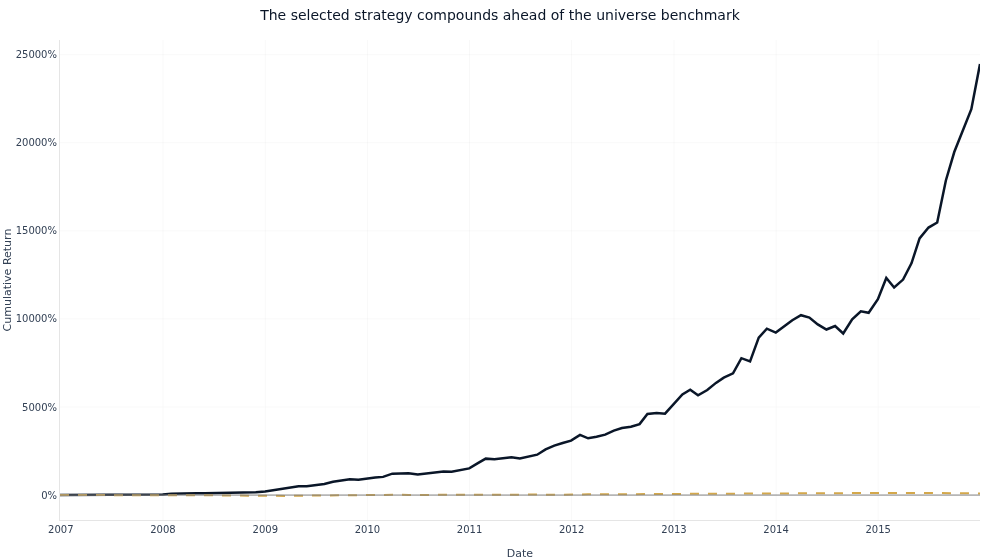

In [35]:
fig_cum = plot_cumulative_returns(pa, benchmark_label="EW universe")
fig_cum.update_layout(title="The selected strategy compounds ahead of the universe benchmark")
fig_cum.show()

**Annual returns.** Calendar-year strategy vs. benchmark bars.

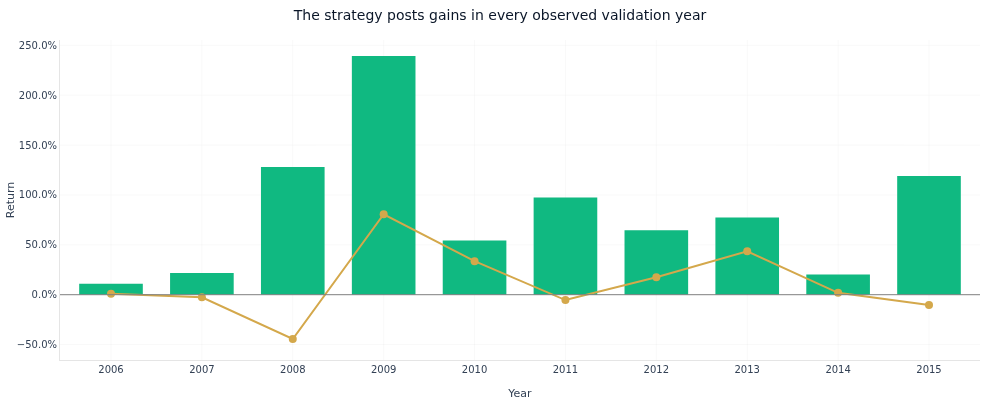

In [36]:
fig_annual = plot_annual_returns_bar(pa, benchmark_label="EW universe")
fig_annual.update_layout(title="The strategy posts gains in every observed validation year")
fig_annual.show()

**Monthly returns heatmap.** Year×month return surface.

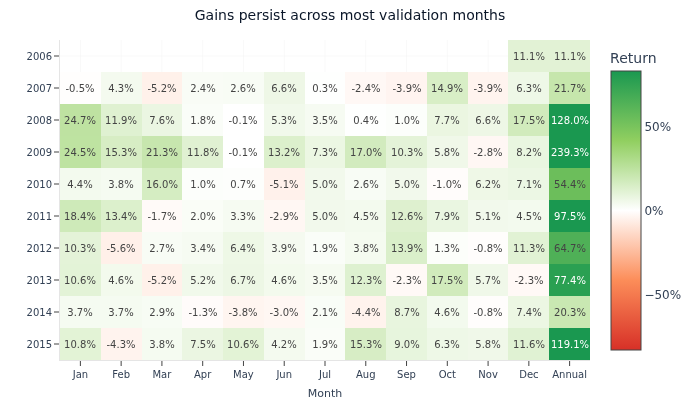

In [37]:
fig_monthly = plot_monthly_returns_heatmap(pa)
fig_monthly.update_layout(title="Gains persist across most validation months")
fig_monthly.show()

**Returns distribution.** Monthly return histogram against a normal
overlay; complements §4's tail-ratio table.

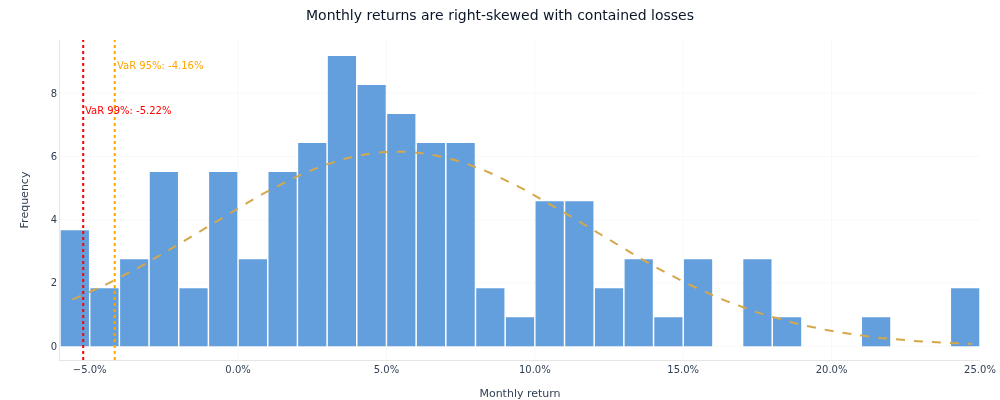

In [38]:
fig_dist = plot_returns_distribution(pa)
fig_dist.update_layout(title="Monthly returns are right-skewed with contained losses")
fig_dist.update_xaxes(title_text="Monthly return")
for annotation, y_position in zip(fig_dist.layout.annotations, [0.92, 0.78], strict=False):
    annotation.update(y=y_position, yshift=0)
fig_dist.show()

**Drawdown underwater.** Underwater curve over the strategy series;
reads against §4's max-drawdown number.

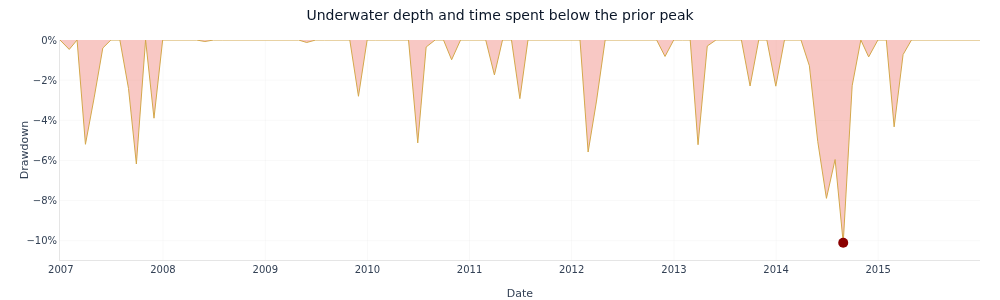

In [39]:
fig_underwater = plot_drawdown_underwater(pa)
fig_underwater.update_layout(title="Underwater depth and time spent below the prior peak")
fig_underwater.show()

**Rolling Sharpe.** Twelve- and 36-month rolling Sharpe locate when the
realized Sharpe is paid out.

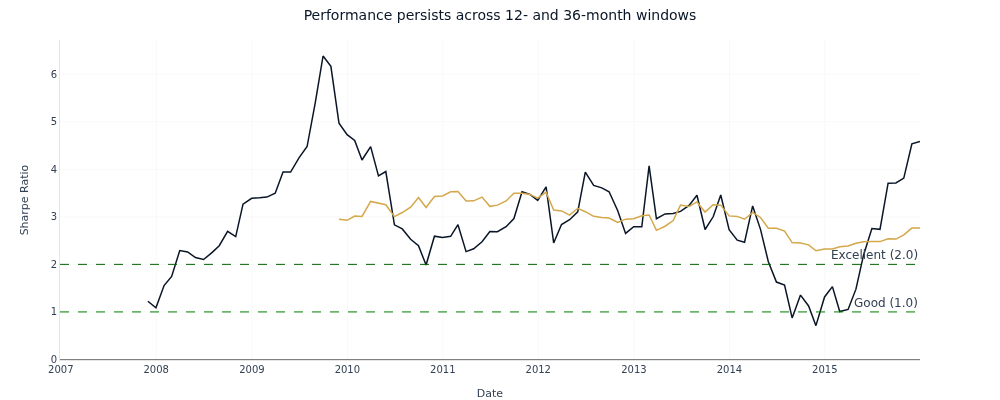

In [40]:
fig_rolling = plot_rolling_sharpe(pa, windows=[12, 36])
for trace, label in zip(fig_rolling.data, ["12 months", "36 months"], strict=False):
    trace.name = label
fig_rolling.update_layout(title="Performance persists across 12- and 36-month windows")
fig_rolling.show()

**Tail risk panel.** Value at risk and conditional value at risk at the two
conventional confidence levels, drawn against the empirical tail.

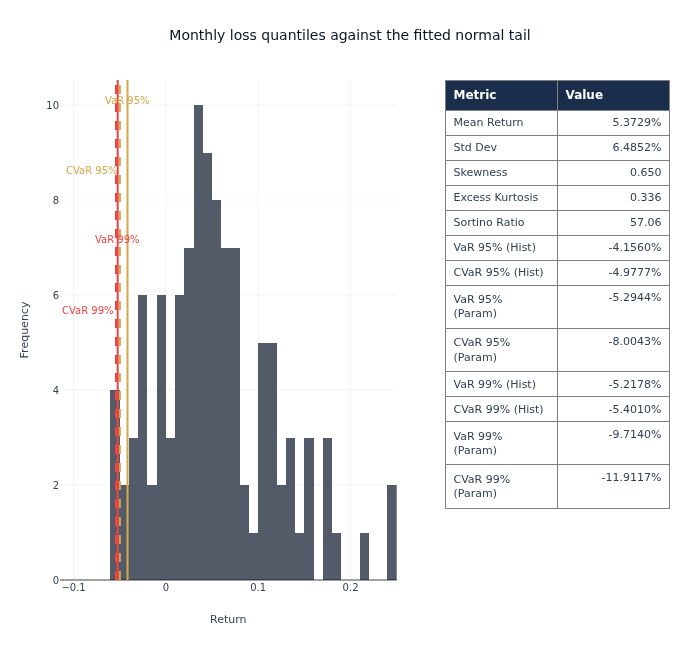

In [41]:
fig_tail = plot_tail_risk_analysis(strat_arr)
_var_99 = float(np.quantile(strat_arr, 0.01))
for annotation, y_position in zip(
    fig_tail.layout.annotations,
    [0.96, 0.82, 0.68, 0.54],
    strict=False,
):
    annotation.update(y=y_position, yanchor="middle")
fig_tail.update_layout(
    title="Monthly loss quantiles against the fitted normal tail",
    height=650,
    margin={"b": 70, "l": 60, "r": 30, "t": 80},
)
fig_tail.show()

## §5 Friction budget & cost sensitivity

Long-short equity at monthly cadence has limited turnover but doubled
cost exposure (long + short legs) and short-leg borrow costs. Two
layers cover the friction budget:

1. **Registry cost sweep** - the cost_sensitivity stage re-ran the selected
   strategy at each level of the declared cost grid, holding everything else
   fixed, so the curve below is the response of this one strategy to friction
   rather than a spread across configurations. `setup.yaml` declares
   `cost_sensitivity: 1`, so exactly one lineage is swept and the curve has one
   Sharpe per level.
2. **Micro-cap-realistic extended grid** - because both long and short
   legs concentrate in small-cap, illiquid names, asset-class-mean
   spreads understate execution costs; the extended grid (up to 500
   bps one-way) and turnover overlay surface the deployment-relevant
   cost regime for the names actually selected.

In [42]:
with sqlite3.connect(str(_db)) as _con:
    cost_df = pl.DataFrame(
        _con.execute(
            """
            SELECT
                b.spec_json,
                bm.sharpe,
                bm.sharpe_ci95_lo,
                bm.sharpe_ci95_hi,
                bm.max_drawdown
            FROM backtest_runs b
            JOIN backtest_metrics bm ON bm.backtest_hash = b.backtest_hash
            JOIN prediction_sets p   ON b.prediction_hash = p.prediction_hash
            WHERE b.stage = 'cost_sensitivity'
              AND p.split = 'validation'
              AND b.prediction_hash = ?
              AND bm.sharpe IS NOT NULL
              AND (bm.num_trades IS NULL OR bm.num_trades > 0)
            """,
            (TOP_PHASH,),
        ).fetchall(),
        schema=[
            "spec_json",
            "sharpe",
            "sharpe_ci95_lo",
            "sharpe_ci95_hi",
            "max_drawdown",
        ],
        orient="row",
    )

In [43]:
def _cost_bps(spec_str: str) -> float:
    spec = json.loads(spec_str)
    bc = spec.get("backtest_config", {})
    comm = bc.get("commission", {}) or {}
    slip = bc.get("slippage", {}) or {}
    return float((comm.get("rate", 0) + slip.get("rate", 0)) * 10000)


cost_df = cost_df.with_columns(
    pl.col("spec_json").map_elements(_cost_bps, return_dtype=pl.Float64).alias("cost_bps")
)
# Empty here means the cost stage swept a different lineage from the one selected
# above, which is a disagreement between two selection paths rather than a missing
# sweep, and it has to stop rather than draw an empty axis.
if cost_df.is_empty():
    raise RuntimeError(
        f"No cost_sensitivity run is registered against the selected prediction "
        f"{TOP_PHASH}. The cost notebook swept a different lineage, so its curve does "
        "not describe the strategy this section reports."
    )
cost_curve = cost_df.select("cost_bps", "sharpe", "sharpe_ci95_lo", "sharpe_ci95_hi").sort(
    "cost_bps"
)
print("Cost sensitivity of the selected strategy (validation):")
with pl.Config(tbl_rows=cost_curve.height):
    print(cost_curve)

Cost sensitivity of the selected strategy (validation):
shape: (22, 4)
┌──────────┬──────────┬────────────────┬────────────────┐
│ cost_bps ┆ sharpe   ┆ sharpe_ci95_lo ┆ sharpe_ci95_hi │
│ ---      ┆ ---      ┆ ---            ┆ ---            │
│ f64      ┆ f64      ┆ f64            ┆ f64            │
╞══════════╪══════════╪════════════════╪════════════════╡
│ 0.0      ┆ 3.115538 ┆ 2.515915       ┆ 3.835339       │
│ 0.0      ┆ 2.9424   ┆ 2.368332       ┆ 3.589304       │
│ 1.0      ┆ 3.109923 ┆ 2.510403       ┆ 3.829734       │
│ 1.0      ┆ 2.936607 ┆ 2.362757       ┆ 3.583973       │
│ 2.0      ┆ 3.104306 ┆ 2.50501        ┆ 3.823184       │
│ 2.0      ┆ 2.930813 ┆ 2.357181       ┆ 3.578641       │
│ 3.0      ┆ 3.098688 ┆ 2.499127       ┆ 3.816495       │
│ 3.0      ┆ 2.925019 ┆ 2.351604       ┆ 3.573308       │
│ 5.0      ┆ 3.08745  ┆ 2.488548       ┆ 3.803113       │
│ 5.0      ┆ 2.913427 ┆ 2.340271       ┆ 3.562641       │
│ 7.0      ┆ 3.076207 ┆ 2.478846       ┆ 3.789754       │
│

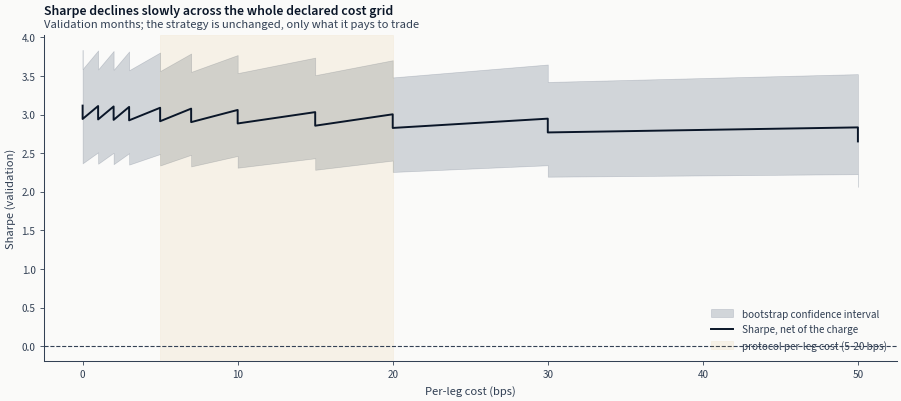

In [44]:
cost_range = setup["costs"]["per_leg_cost_bps_range"]
fig, ax = plt.subplots(figsize=(9, 4))
xs = cost_curve["cost_bps"].to_numpy()
ax.fill_between(
    xs,
    cost_curve["sharpe_ci95_lo"].to_numpy(),
    cost_curve["sharpe_ci95_hi"].to_numpy(),
    alpha=0.18,
    color=COLORS["slate"],
    label="bootstrap confidence interval",
)
ax.plot(
    xs,
    cost_curve["sharpe"].to_numpy(),
    color=COLORS["blue"],
    linewidth=1.4,
    label="Sharpe, net of the charge",
)
ax.axhline(0, color=COLORS["neutral"], linewidth=0.8, linestyle="--")
ax.axvspan(
    cost_range[0],
    cost_range[1],
    color=COLORS["amber"],
    alpha=0.10,
    label=f"protocol per-leg cost ({cost_range[0]}-{cost_range[1]} bps)",
)
ax.set_xlabel("Per-leg cost (bps)")
ax.set_ylabel("Sharpe (validation)")
add_message_title(
    ax,
    "Sharpe declines slowly across the whole declared cost grid",
    subtitle="Validation months; the strategy is unchanged, only what it pays to trade",
)
ax.legend(loc="best", fontsize=8, frameon=False)
fig.show()

In [45]:
_crossed = cost_curve.filter(pl.col("sharpe_ci95_lo") <= 0).sort("cost_bps")
if _crossed.height == cost_curve.height:
    print("The Sharpe CI lower bound is at or below zero at every level of the grid.")
elif _crossed.is_empty():
    print(
        f"The Sharpe CI lower bound is above zero at every level up to "
        f"{cost_curve['cost_bps'].max():.0f} bps, the top of the grid, so the level at "
        "which it would cross lies outside the range swept."
    )
else:
    # The first level whose bound reaches zero, not the last one above it. Those are
    # adjacent grid points, and reporting the level below the crossing as the crossing
    # overstates what the strategy tolerates by one step of the grid.
    _first = _crossed["cost_bps"][0]
    _below = cost_curve.filter(pl.col("cost_bps") < _first)["cost_bps"]
    _last_ok = f"{_below.max():.0f}" if _below.len() else "none"
    print(
        f"The Sharpe CI lower bound first reaches zero at {_first:.0f} bps per leg; the "
        f"highest level still clear of it is {_last_ok} bps. The crossing lies between "
        "those two, and the grid does not resolve it more finely."
    )

print(
    f"Protocol per-leg cost: {cost_range} bps. "
    f"Borrow note: {setup['costs'].get('borrow_cost_note', '-')}. "
    f"Era note: {setup['costs'].get('era_note', '-')}."
)
print("See Chapter 18 for transaction-cost framework details.")

The Sharpe CI lower bound is above zero at every level up to 50 bps, the top of the grid, so the level at which it would cross lies outside the range swept.
Protocol per-leg cost: [5, 20] bps. Borrow note: Long-short requires borrow for the short leg.. Era note: Pre-2001 spreads 15-30 bps; post-2001 (decimalization) 5-15 bps..
See Chapter 18 for transaction-cost framework details.


The line printed above brackets the crossing rather than naming a level: the first
swept cost whose confidence interval reaches zero, and the highest one still clear of
it. The crossing is somewhere between, and a grid of eleven levels cannot say where.
If no level reaches zero the line says so, which is the weaker statement - it puts the
crossing beyond the range tested rather than at a cost.

What makes the decline slow is turnover rather than the cost assumption: a monthly
rebalance into a fixed number of names replaces only part of the book each period,
and cost is paid on what changes hands, so erosion scales with round-trip cost times
turnover and not with the spread alone.

This curve answers whether broker fees at the asset-class-mean spread would
consume the edge. It cannot answer whether the strategy trades at that
spread, and the next sub-section shows that it does not.

### Illiquidity profile of selected stocks

The allocation weights say which names were actually held each month.
Joining them to the prepared feature panel describes the implemented book's
liquidity, and it does so without sorting on realized returns: the join key
is the position the strategy took, not what that position went on to earn.

In [46]:
_attr_returns_path = strat_returns_path
_strategy_rets = pd.Series(
    pl.read_parquet(_attr_returns_path).sort("timestamp")["daily_return"].to_numpy(),
    index=pd.to_datetime(
        pl.read_parquet(_attr_returns_path).sort("timestamp")["timestamp"].to_list()
    ),
    name="strategy",
)
_start = str(_strategy_rets.index.min().date())
_end = str(_strategy_rets.index.max().date())

_liq_features = ["LME", "Spread", "LTurnover", "IdioVol"]
_weights_path = CASE_DIR / "run_log" / "backtest" / TOP_HASH / "weights.parquet"
_weights = pl.read_parquet(_weights_path).select(
    pl.col("timestamp").cast(pl.Date),
    pl.col("symbol").cast(pl.String),
    "weight",
)
_features = (
    pl.scan_parquet(CASE_DIR / "features" / "financial.parquet")
    .select(
        pl.col("timestamp").cast(pl.Date),
        pl.col("symbol").cast(pl.String),
        *_liq_features,
    )
    .filter(pl.col("timestamp").is_in(_weights["timestamp"].unique().implode()))
    .collect()
)
_selected = _weights.join(_features, on=["timestamp", "symbol"], how="inner", validate="m:1")
if _selected.height != _weights.height:
    raise RuntimeError("Every realized portfolio weight must match one prepared feature row.")

In [47]:
_selected_long = _selected.with_columns(
    pl.when(pl.col("weight") > 0).then(pl.lit("Long")).otherwise(pl.lit("Short")).alias("segment")
).unpivot(index="segment", on=_liq_features, variable_name="feature", value_name="value")
_universe_long = _features.unpivot(
    on=_liq_features, variable_name="feature", value_name="value"
).with_columns(pl.lit("Universe").alias("segment"))
_liq_df = (
    pl.concat([_selected_long, _universe_long], how="diagonal")
    .group_by("segment", "feature")
    .agg(pl.col("value").mean().alias("mean"))
    .sort("feature", "segment")
)
print("Actual-weight liquidity profile (rank-normalized features):")
_liq_df

Actual-weight liquidity profile (rank-normalized features):


segment,feature,mean
str,str,f64
"""Long""","""IdioVol""",0.380246
"""Short""","""IdioVol""",0.375674
"""Universe""","""IdioVol""",-3.3746e-17
"""Long""","""LME""",-0.40108
"""Short""","""LME""",-0.268727
…,…,…
"""Short""","""LTurnover""",0.006774
"""Universe""","""LTurnover""",-2.1034e-17
"""Long""","""Spread""",0.401315


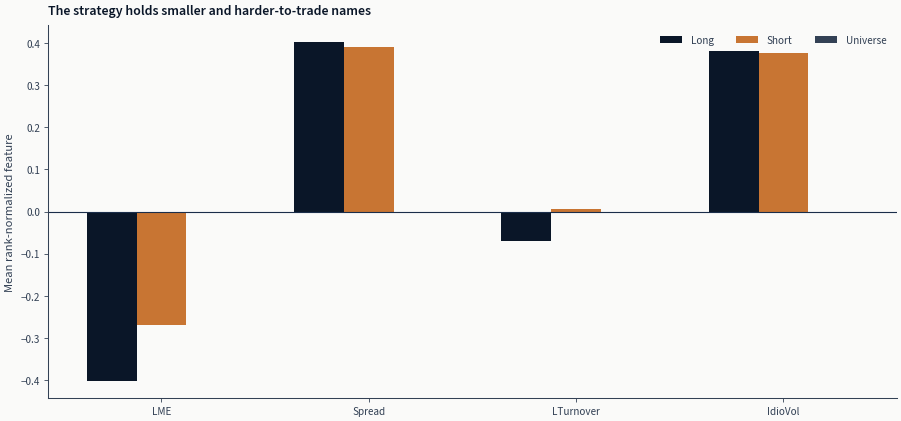

In [48]:
_liq_wide = _liq_df.pivot(on="segment", index="feature", values="mean")
_x = np.arange(len(_liq_features))
fig_liq, ax_liq = plt.subplots(figsize=(9, 4.2), constrained_layout=True)
for _offset, (_segment, _color) in enumerate(
    [("Long", COLORS["blue"]), ("Short", COLORS["copper"]), ("Universe", COLORS["neutral"])]
):
    _values = [
        _liq_wide.filter(pl.col("feature") == feature)[_segment][0] for feature in _liq_features
    ]
    ax_liq.bar(_x + (_offset - 1) * 0.24, _values, 0.24, label=_segment, color=_color)
ax_liq.axhline(0, color=COLORS["slate"], linewidth=0.8)
ax_liq.set_xticks(_x, _liq_features)
ax_liq.set_ylabel("Mean rank-normalized feature")
add_message_title(ax_liq, "The strategy holds smaller and harder-to-trade names")
ax_liq.legend(frameon=False, ncol=3)
fig_liq.show()

Negative LME denotes smaller firms; positive Spread, LTurnover, and
IdioVol denote more difficult execution. The chart measures those
properties on realized holdings. It does not infer positions from
future returns or translate normalized features into basis points.

### Extended cost grid (micro-cap-realistic)

Because the registry's cost_sensitivity stage caps at 50 bps per leg,
we extend the grid to micro-cap-realistic spreads, scaling the strategy's
gross monthly returns by an explicit turnover times cost product. This is
the Avramov, Cheng and Metzker (2020) critique applied to this case study:
machine-learning profitability measured at universe-mean spreads can erode
once the trading restrictions on the names actually selected are priced in.

In [49]:
_turnover_pcts = [0.10, 0.25, 0.50, 0.75, 1.00]
_cost_bps_extended = [0, 10, 50, 100, 200, 300, 500]
_grid_ext = []

for turnover in _turnover_pcts:
    for cost_bps in _cost_bps_extended:
        cost_per_period = turnover * 2 * (cost_bps / 10_000)
        adj_rets = _strategy_rets - cost_per_period
        sharpe_adj = (
            float(adj_rets.mean() / adj_rets.std() * np.sqrt(PERIODS_PER_YEAR))
            if adj_rets.std() > 0
            else 0.0
        )
        _grid_ext.append(
            {
                "turnover_pct": turnover,
                "cost_bps": cost_bps,
                "sharpe": sharpe_adj,
                "annual_drag": cost_per_period * PERIODS_PER_YEAR,
            }
        )

_ext_df = pd.DataFrame(_grid_ext)
_ext_heat = _ext_df.pivot(index="turnover_pct", columns="cost_bps", values="sharpe")

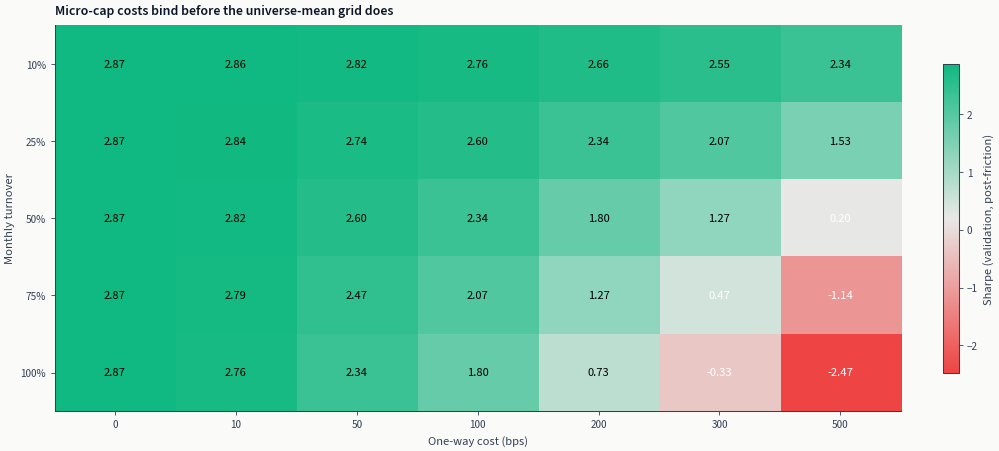

In [50]:
_cost_cmap = LinearSegmentedColormap.from_list("ml4t_cost", ml4t_diverging())

fig_ext, ax_ext = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
im = ax_ext.imshow(
    _ext_heat.values,
    cmap=_cost_cmap,
    aspect="auto",
    vmin=min(0, _ext_heat.values.min()),
    vmax=_ext_heat.values.max(),
)
ax_ext.set_xticks(range(len(_cost_bps_extended)))
ax_ext.set_xticklabels([f"{c}" for c in _cost_bps_extended])
ax_ext.set_yticks(range(len(_turnover_pcts)))
ax_ext.set_yticklabels([f"{t:.0%}" for t in _turnover_pcts])
ax_ext.set_xlabel("One-way cost (bps)")
ax_ext.set_ylabel("Monthly turnover")
add_message_title(ax_ext, "Micro-cap costs bind before the universe-mean grid does")
for i in range(len(_turnover_pcts)):
    for j in range(len(_cost_bps_extended)):
        val = _ext_heat.values[i, j]
        color = "white" if val < 0.5 else "black"
        ax_ext.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9, color=color)
fig_ext.colorbar(im, ax=ax_ext, label="Sharpe (validation, post-friction)", shrink=0.8)
fig_ext.show()

In [51]:
print("Extended turnover × cost sensitivity (Sharpe ratios):")
pl.from_pandas(_ext_heat.reset_index())

Extended turnover × cost sensitivity (Sharpe ratios):


turnover_pct,0,10,50,100,200,300,500
f64,f64,f64,f64,f64,f64,f64,f64
0.1,2.869934,2.859251,2.816519,2.763104,2.656273,2.549443,2.335782
0.25,2.869934,2.843226,2.736396,2.602858,2.335782,2.068706,1.534554
0.5,2.869934,2.816519,2.602858,2.335782,1.80163,1.267479,0.199175
0.75,2.869934,2.789811,2.46932,2.068706,1.267479,0.466251,-1.136205
1.0,2.869934,2.763104,2.335782,1.80163,0.733327,-0.334977,-2.471584


In [52]:
for turnover in _turnover_pcts:
    row = _ext_df[_ext_df["turnover_pct"] == turnover].sort_values("cost_bps")
    positive = row[row["sharpe"] > 0]
    if positive.empty:
        print(f"  Turnover {turnover:.0%}: negative at all cost levels")
    elif len(positive) < len(row):
        max_cost = int(positive.iloc[-1]["cost_bps"])
        print(f"  Turnover {turnover:.0%}: positive up to {max_cost} bps one-way")
    else:
        print(
            f"  Turnover {turnover:.0%}: positive at all levels "
            f"(max tested: {_cost_bps_extended[-1]} bps)"
        )

  Turnover 10%: positive at all levels (max tested: 500 bps)
  Turnover 25%: positive at all levels (max tested: 500 bps)
  Turnover 50%: positive at all levels (max tested: 500 bps)
  Turnover 75%: positive up to 300 bps one-way
  Turnover 100%: positive up to 200 bps one-way


The grid above is a set of scenarios, not a cost estimate: nothing here
measures what this book would actually have paid. Each cell asks what the
Sharpe would have been at an assumed turnover and an assumed one-way cost,
and the reader supplies the assumption. Its use is to locate where the
result stops holding, which is a property of the strategy, rather than to
predict a number.

Neither gate in §9 reads this grid, so nothing here changes the gate
outcome. It is a capacity caveat: a deployment could restrict the universe
to names above a liquidity threshold, which would also shrink the
long-short spread it is trying to capture, or treat the gross figure as an
upper bound on what this feature set extracts. Chapter 18 develops the
transaction-cost framework that turns this grid into a decision.

## §6 Holdout closure with paired bootstrap

The holdout is a single calendar year of monthly observations. That is few
enough that a paired-bootstrap interval will be wide whatever the effect is,
so a CI covering zero here says the window cannot resolve the difference and
does not say the difference is absent. Reading it the other way is the error
this section is arranged to prevent.

Two paired tests close the case study. The first compares the holdout
backtest that uniquely matches the selected run's complete strategy spec within
its training lineage against that same run's validation record: did the
Sharpe carry? The second compares that holdout backtest against the
holdout-window equal-weight benchmark: did selecting names do better than
holding the universe?

Both numbers come from `backtest_paired_metrics`, which bootstraps the two
series jointly. Neither is validation Sharpe minus holdout Sharpe: that
difference has no interval, and the sampling error of the two windows does
not subtract.

In [53]:
print(f"Selected validation backtest: {TOP_HASH}")
print(f"Holdout mate hash:       {HO_HASH}")
print(f"Selected strategy: {RANK1_FAMILY}/{RANK1_CONFIG}/{RANK1_LABEL}, {RANK1_ALLOCATOR}")

ho_full = load_backtest_metrics(CASE_STUDY, backtest_hash=HO_HASH).row(0, named=True)
val_full = full

Selected validation backtest: 2a0b06e45e26
Holdout mate hash:       d8bc220e6fa5
Selected strategy: gbm/leaves_63_mse/fwd_ret_1m, conformal_weighted


In [54]:
val_ho_pair = load_paired_metrics(
    CASE_STUDY,
    challenger_hash=HO_HASH,
    benchmark_kind="val_rank1_self",
)
if val_ho_pair.is_empty():
    raise RuntimeError("Missing required val_rank1_self paired metric.")
if val_ho_pair.height != 1 or val_ho_pair["benchmark_hash"].item() != TOP_HASH:
    raise RuntimeError("Validation-to-holdout pair does not identify the frozen run exactly.")
vh = val_ho_pair.row(0, named=True)

In [55]:
def _diff_row(
    label: str,
    v: float,
    h: float,
    diff: float | None,
    lo: float | None,
    hi: float | None,
    p: float | None,
) -> dict:
    return {
        "metric": label,
        "validation": _fmt(v, ".4f"),
        "holdout": _fmt(h, ".4f"),
        "diff (h-v)": _fmt(diff, ".4f") if diff is not None else "-",
        "diff CI95": f"[{_fmt(lo, '.4f')}, {_fmt(hi, '.4f')}]" if lo is not None else "-",
        "p-value": _fmt(p, ".4f") if p is not None else "-",
    }

In [56]:
val_ho_rows = [
    _diff_row(
        "Sharpe",
        val_full["sharpe"],
        ho_full["sharpe"],
        vh["sharpe_diff"],
        vh["sharpe_diff_ci95_lo"],
        vh["sharpe_diff_ci95_hi"],
        vh["p_value"],
    ),
    _diff_row(
        "Annualized return",
        val_full["cagr"],
        ho_full["cagr"],
        vh["ret_diff"],
        vh["ret_diff_ci95_lo"],
        vh["ret_diff_ci95_hi"],
        None,
    ),
]

In [57]:
val_ho_rows.extend(
    [
        _diff_row(
            "Max drawdown",
            val_full["max_drawdown"],
            ho_full["max_drawdown"],
            vh["max_dd_diff"],
            vh["max_dd_diff_ci95_lo"],
            vh["max_dd_diff_ci95_hi"],
            None,
        ),
        _diff_row(
            "Information ratio",
            None,
            None,
            vh["info_ratio"],
            vh["info_ratio_ci95_lo"],
            vh["info_ratio_ci95_hi"],
            None,
        ),
    ]
)
val_ho_table = pl.DataFrame(val_ho_rows)
print("Validation to holdout, paired bootstrap, the selected run against itself:")
print(val_ho_table)
print(f"prob_challenger_wins: {vh['prob_challenger_wins']:.3f}")
print(f"CI status (Sharpe diff): {ci_status(vh['sharpe_diff_ci95_lo'], vh['sharpe_diff_ci95_hi'])}")
print()
print(
    f"Note: validation has {int(val_full['n_periods'])} monthly observations; "
    f"holdout has {int(ho_full['n_periods'])}. The "
    "populator's `_min_paired_n(ppy=12)` floor of 6 admits this pair; CI "
    "width reflects the 12-period truncated draw."
)

Validation to holdout, paired bootstrap, the selected run against itself:
shape: (4, 6)
┌───────────────────┬────────────┬─────────┬────────────┬───────────────────┬─────────┐
│ metric            ┆ validation ┆ holdout ┆ diff (h-v) ┆ diff CI95         ┆ p-value │
│ ---               ┆ ---        ┆ ---     ┆ ---        ┆ ---               ┆ ---     │
│ str               ┆ str        ┆ str     ┆ str        ┆ str               ┆ str     │
╞═══════════════════╪════════════╪═════════╪════════════╪═══════════════════╪═════════╡
│ Sharpe            ┆ 2.8699     ┆ 4.1978  ┆ 1.3278     ┆ [-0.2427, 4.3701] ┆ 0.2175  │
│ Annualized return ┆ 0.8330     ┆ 2.3682  ┆ 1.5352     ┆ [0.1545, 3.9801]  ┆ -       │
│ Max drawdown      ┆ -0.1010    ┆ -0.0041 ┆ 0.0969     ┆ [0.0481, 0.1508]  ┆ -       │
│ Information ratio ┆ -          ┆ -       ┆ -          ┆ -                 ┆ -       │
└───────────────────┴────────────┴─────────┴────────────┴───────────────────┴─────────┘
prob_challenger_wins: 0.948
CI s

In [58]:
ho_vs_ew = load_paired_metrics(
    CASE_STUDY,
    challenger_hash=HO_HASH,
    benchmark_kind="equal_weight_holdout_side_artifact",
)
if ho_vs_ew.is_empty():
    raise RuntimeError("Missing required equal_weight_holdout_side_artifact pair.")
he = ho_vs_ew.row(0, named=True)

ew_ho = load_benchmark_metrics(CASE_STUDY, RANK1_LABEL, period="holdout")
print("Holdout strategy vs holdout EW universe:")
print(f"  strategy Sharpe:    {ho_full['sharpe']:.3f}")
print(f"  EW Sharpe:          {ew_ho['sharpe']:.3f}")
print(
    "  diff Sharpe: "
    f"{_fmt_ci(he['sharpe_diff'], he['sharpe_diff_ci95_lo'], he['sharpe_diff_ci95_hi'])}"
)
print(f"  p_value:                {he['p_value']:.4f}")
print(f"  prob_challenger_wins:   {he['prob_challenger_wins']:.3f}")
print(
    f"  info_ratio (strategy vs EW): "
    f"{_fmt_ci(he['info_ratio'], he['info_ratio_ci95_lo'], he['info_ratio_ci95_hi'])}"
)
print(f"  CI status: {ci_status(he['sharpe_diff_ci95_lo'], he['sharpe_diff_ci95_hi'])}")

Holdout strategy vs holdout EW universe:
  strategy Sharpe:    4.198
  EW Sharpe:          1.411
  diff Sharpe: 2.787 [-0.241, 6.550]
  p_value:                0.1085
  prob_challenger_wins:   0.963
  info_ratio (strategy vs EW): 3.046 [1.309, 6.465]
  CI status: straddles_zero


**Decay reading.** Read the two tables above in the same order the tests
were defined. The first row is the strategy against itself across the split:
a point estimate close to zero would mean the Sharpe carried, and the
interval says whether one year can tell. The second is the strategy against
the holdout-window equal-weight universe.

Where an interval covers zero on a window this short, the honest statement
is that the holdout did not resolve the comparison. It is not evidence that
the strategy decayed, and it is not evidence that it persisted. The status
column names which of those two situations each row is in, and neither of
them is a result about the strategy's edge.

## §7 Benchmark-aware diagnostics

Layer 1 reports the universal alpha/beta/IR profile via
`PortfolioAnalysis` against the equal-weight universe. Layer 2, equity
factor attribution (FF5+MOM), applies because the case study is an
equity-class CS; we further include a placebo random-portfolio
benchmark to separate signal-driven factor exposure from
universe-driven exposure.

In [59]:
metrics = pa.compute_summary_stats()
attr_df = pl.DataFrame(
    [
        {"metric": "alpha (annualized)", "value": _fmt(getattr(metrics, "alpha", None))},
        {"metric": "beta", "value": _fmt(getattr(metrics, "beta", None), ".3f")},
        {"metric": "information ratio", "value": _fmt(getattr(metrics, "information_ratio", None))},
        {"metric": "tracking error", "value": _fmt(getattr(metrics, "tracking_error", None))},
        {"metric": "up capture", "value": _fmt(getattr(metrics, "up_capture", None))},
        {"metric": "down capture", "value": _fmt(getattr(metrics, "down_capture", None))},
    ]
)
print("Layer 1: the selected run against the validation equal-weight universe:")
print(attr_df)

Layer 1: the selected run against the validation equal-weight universe:
shape: (6, 2)
┌────────────────────┬──────────┐
│ metric             ┆ value    │
│ ---                ┆ ---      │
│ str                ┆ str      │
╞════════════════════╪══════════╡
│ alpha (annualized) ┆ 0.6413   │
│ beta               ┆ 0.036    │
│ information ratio  ┆ 1.8039   │
│ tracking error     ┆ -        │
│ up capture         ┆ 1.1151   │
│ down capture       ┆ 114.2310 │
└────────────────────┴──────────┘


### Layer 2 - FF5+MOM factor attribution

Many of the firm characteristics in this feature set are themselves proxies
for, or components of, the FF5+MOM factors: book-to-market, operating
profitability, asset growth and momentum all appear on both sides. So a
model fitted on them may be reproducing a factor portfolio rather than
finding anything past one. The regression measures how much of the strategy's
return those common factors span, and whether a residual remains.

In [60]:
_factors = load_factor_data(start=_start, end=_end)
_reg = run_factor_regression(
    _strategy_rets, _factors, model="ff5_mom", hac_lags=4, dollar_neutral=True
)

print(f"""
FF5+MOM regression (HAC, lags=4):
Observations:     {_reg["n_obs"]}
Strategy Sharpe:  {_reg["strategy_sharpe"]:+.2f}
Residual Sharpe:  {_reg["residual_sharpe"]:+.2f}
R²:               {_reg["r_squared"]:.3f}
Alpha (ann.):     {_reg["alpha_annualized"]:+.1%} (t={_reg["alpha_t_stat"]:.2f}, p={_reg["alpha_p_value"]:.3f})
""")

print("Factor betas:")
for factor, beta in _reg["betas"].items():
    t = _reg["t_stats"][factor]
    sig = "*" if _reg["p_values"][factor] < 0.05 else ""
    print(f"  {factor:8s}: {beta:+.4f}  (t={t:+.2f}){sig}")


FF5+MOM regression (HAC, lags=4):
Observations:     109
Strategy Sharpe:  +2.87
Residual Sharpe:  +3.34
R²:               0.141
Alpha (ann.):     +69.2% (t=7.33, p=0.000)

Factor betas:
  Mkt-RF  : -0.4158  (t=-2.12)*
  SMB     : +0.2784  (t=+1.09)
  HML     : -0.3291  (t=-0.84)
  RMW     : -0.6038  (t=-1.29)
  CMA     : +1.1130  (t=+2.99)*
  MOM     : -0.3980  (t=-2.09)*


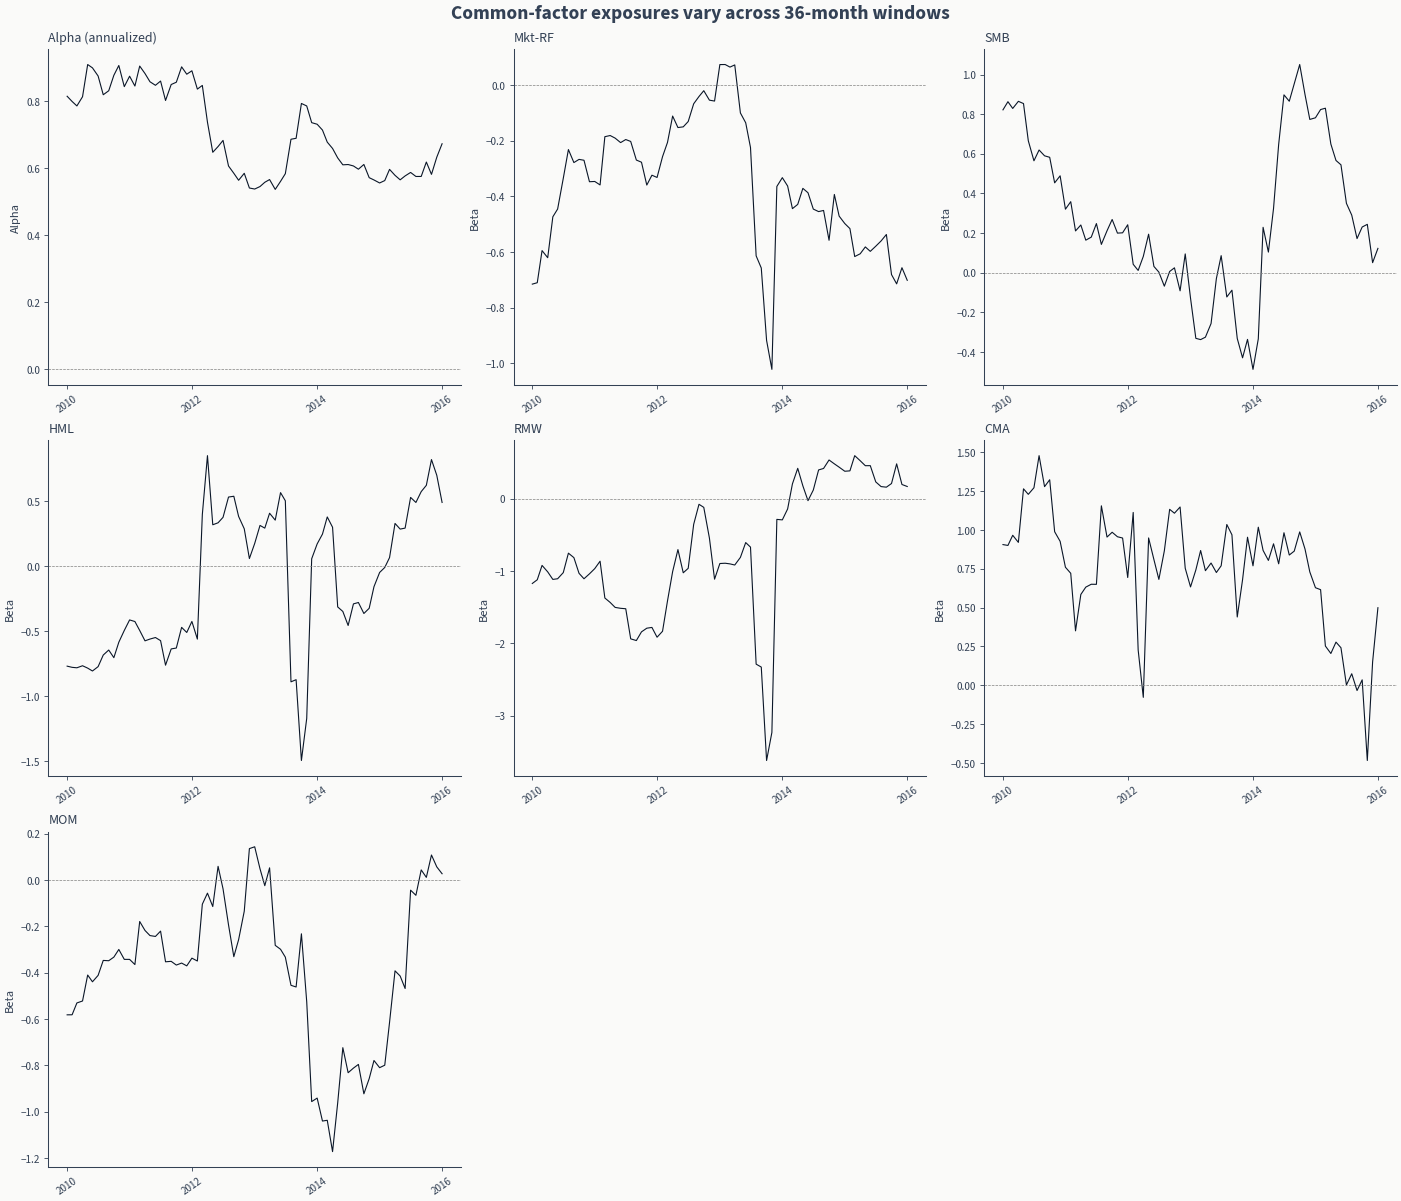

In [61]:
_rolling = compute_rolling_exposures(
    _strategy_rets, _factors, model="ff5_mom", window=36, dollar_neutral=True
)
fig_roll = plot_rolling_exposures(
    _rolling, title="Common-factor exposures vary across 36-month windows"
)
for _ax in fig_roll.axes:
    _ax.xaxis.set_major_locator(mdates.YearLocator(2))
    _ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    _ax.tick_params(axis="x", rotation=35)
fig_roll.show()

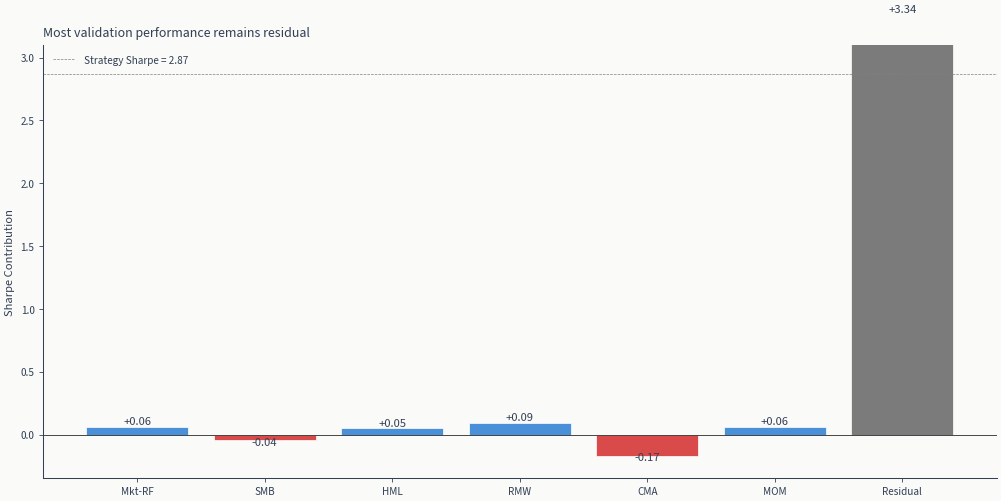

In [62]:
fig_attr = plot_attribution_waterfall(_reg, title="Most validation performance remains residual")
fig_attr.axes[0].set_ylim(top=3.1)
fig_attr.axes[0].legend(loc="upper left", frameon=False)
fig_attr.show()

In [63]:
_boot = compute_bootstrap_ci(
    _strategy_rets,
    _factors,
    model="ff5_mom",
    n_boot=1000,
    block_size=4,
    dollar_neutral=True,
    seed=SEED,
)

if _boot.get("n_boot", 0) > 0:
    print(f"Bootstrap CIs (n={_boot['n_boot']}, block=4 months):")
    print(f"  Alpha (ann.): [{_boot['alpha_ann_lo']:+.1%}, {_boot['alpha_ann_hi']:+.1%}]")
    for factor in _reg["factor_columns"]:
        key_lo = f"{factor}_lo"
        key_hi = f"{factor}_hi"
        if key_lo in _boot:
            print(f"  {factor:8s}: [{_boot[key_lo]:+.4f}, {_boot[key_hi]:+.4f}]")

Bootstrap CIs (n=1000, block=4 months):
  Alpha (ann.): [+50.7%, +87.3%]
  Mkt-RF  : [-0.7983, -0.0489]
  SMB     : [-0.2672, +0.8161]
  HML     : [-0.8282, +0.8479]
  RMW     : [-1.4860, +0.4708]
  CMA     : [+0.1122, +1.7647]
  MOM     : [-0.7359, +0.0550]


### Placebo benchmark: random dollar-neutral portfolios

To separate signal-driven factor exposure from universe-driven exposure, the cell
below draws random dollar-neutral portfolios from the same universe and compares the
strategy's factor loadings against that distribution.

Each random book holds as many names per leg as the selected strategy does, read from
its spec rather than fixed here. A random portfolio of a different size has different
factor exposures by construction, so a fixed count would compare the strategy against
books it was never competing with the moment the selected concentration changed.

In [64]:
_prices_path = CASE_DIR / "labels" / "prices.parquet"
if _prices_path.exists():
    _returns = (
        pl.scan_parquet(_prices_path)
        .select(
            pl.col("timestamp").cast(pl.Date),
            pl.col("symbol").cast(pl.String),
            "ret",
        )
        .filter(
            pl.col("timestamp").is_between(_strategy_rets.index.min(), _strategy_rets.index.max())
        )
        .collect()
    )
    _fc_wide = _returns.pivot(on="symbol", index="timestamp", values="ret").to_pandas()
    _fc_wide = _fc_wide.set_index("timestamp")
    _fc_wide.index = pd.to_datetime(_fc_wide.index)

    _placebo = run_placebo_benchmark(
        _fc_wide,
        _factors,
        n_sims=500,
        top_k=RANK1_TOP_K,
        model="ff5_mom",
        seed=SEED,
        periods_per_year=PERIODS_PER_YEAR,
    )

In [65]:
if _prices_path.exists():
    if _placebo["n_sims"] > 0:
        print(
            f"Placebo benchmark ({_placebo['n_sims']} random dollar-neutral "
            f"portfolios of {RANK1_TOP_K} names per leg):"
        )
        print(
            f"  Random Mkt-RF: {_placebo['Mkt-RF_mean']:+.3f} "
            f"[{_placebo['Mkt-RF_p5']:+.3f}, {_placebo['Mkt-RF_p95']:+.3f}]"
        )
        print(
            f"  Random SMB:    {_placebo['SMB_mean']:+.3f} "
            f"[{_placebo['SMB_p5']:+.3f}, {_placebo['SMB_p95']:+.3f}]"
        )
        print(
            f"  Random HML:    {_placebo['HML_mean']:+.3f} "
            f"[{_placebo['HML_p5']:+.3f}, {_placebo['HML_p95']:+.3f}]"
        )
        print(
            f"  Random alpha (ann): {_placebo['alpha_ann_mean']:+.1%} "
            f"± {_placebo['alpha_ann_std']:.1%}"
        )
        print(f"  Random R²:     {_placebo['r_squared_mean']:.3f}")
        print()

        for factor in ["Mkt-RF", "SMB", "HML"]:
            strat_beta = _reg["betas"].get(factor, 0)
            p5 = _placebo[f"{factor}_p5"]
            p95 = _placebo[f"{factor}_p95"]
            inside = "within" if p5 <= strat_beta <= p95 else "OUTSIDE"
            print(
                f"  Strategy {factor}: {strat_beta:+.3f} - {inside} random 90% CI "
                f"[{p5:+.3f}, {p95:+.3f}]"
            )
else:
    _placebo = {"n_sims": 0}
    print("Prices parquet not found - placebo benchmark skipped.")

Placebo benchmark (500 random dollar-neutral portfolios of 50 names per leg):
  Random Mkt-RF: -0.001 [-0.591, +0.616]
  Random SMB:    -0.025 [-1.181, +1.070]
  Random HML:    -0.023 [-1.633, +1.625]
  Random alpha (ann): +0.1% ± 3.9%
  Random R²:     0.073

  Strategy Mkt-RF: -0.416 - within random 90% CI [-0.591, +0.616]
  Strategy SMB: +0.278 - within random 90% CI [-1.181, +1.070]
  Strategy HML: -0.329 - within random 90% CI [-1.633, +1.625]


**Layer 1 / Layer 2 reading.** The regression's R-squared says how much of
the monthly return variation the common factors span; what is left is the
residual the model would have to be earning if it is doing something the
factors do not.

A significant loading is not by itself evidence of stock picking, which is
what the placebo comparison is for. Five hundred random dollar-neutral
portfolios drawn from the same universe inherit that universe's factor
tilts, so a strategy beta that falls **inside** their interval is telling
you about the universe rather than about the model. Only a beta **outside**
it is attributable to selection. Read each coefficient against its placebo
interval before reading it as a finding.

## §8 Strategy tear sheet

The diagnostic library renders the selected lineage's tear sheet directly
from on-disk artifacts. This case study runs through the
vectorized backtester, which emits `daily_returns.parquet`,
`weights.parquet`, and `spec.json` but **no** `trades.parquet`:
the source dataset (US firm characteristics) carries portfolio
returns directly without an underlying fill stream. The bridge layer
that builds a `BacktestProfile` for the standalone tear-sheet HTML
requires per-trade fills, so the tear sheet is intentionally
unavailable here. Per strategy-analysis convention we do not synthesize trades.

What the tear sheet would have shown is split across other sections:

- **Returns and equity:** §3 forest plot, §3 equity overlay, §3
  sub-period decomposition.
- **Risk panels:** §4 drawdown analysis, §4b inline returns
  distribution / drawdown underwater / rolling Sharpe / tail risk.
- **Holdout closure:** §6 paired-bootstrap CI.
- **Factor attribution:** §7 FF5+MOM regression and rolling
  exposures.
- **ML / IC diagnostics:** §3 forest plot summarises the prediction-
  side IC with HAC CI; the trade-conditional alignment view a tear
  sheet would carry is unavailable for the same fill-stream reason.

This is a case-study-shape note, not a result. Datasets that carry
only portfolio returns will always trade tear-sheet richness for
pipeline simplicity; the diagnostic surfaces above carry the same
evidence in modular form.

In [66]:
backtest_dir = CASE_DIR / "run_log" / "backtest" / TOP_HASH
ho_dir = CASE_DIR / "run_log" / "backtest" / HO_HASH
trades_present = (backtest_dir / "trades.parquet").exists()
ho_trades_present = (ho_dir / "trades.parquet").exists()
print(f"Validation backtest_dir: {display_path(backtest_dir)}")
print(f"  trades.parquet present:   {trades_present}")
print(f"  daily_returns.parquet:    {(backtest_dir / 'daily_returns.parquet').exists()}")
print(f"  weights.parquet:          {(backtest_dir / 'weights.parquet').exists()}")
print()
print(f"Holdout backtest_dir:    {display_path(ho_dir)}")
print(f"  trades.parquet present:   {ho_trades_present}")
print()

if trades_present:
    bench_series = bench_val.rename({"benchmark": "ew_return"})["ew_return"].to_numpy()
    meta = BacktestReportMetadata(
        title="US Firm Characteristics - Rank-1 Lineage",
        strategy_name=f"{RANK1_FAMILY}/{RANK1_CONFIG} - {RANK1_LABEL}",
        universe=("~2,500 US firms (filters: min_price=$5, min_ADV=$1M, ex-financials/REITs/ADRs)"),
        benchmark_name="EW universe (validation)",
        evaluation_window=f"{aligned['ts'].min()} to {aligned['ts'].max()}",
        calendar=setup["evaluation"].get("calendar") or "NYSE",
    )
    tear_path = OUTPUT_DIR / f"{CASE_STUDY}_tearsheet.html"
    html = generate_tearsheet_from_run_artifacts(
        backtest_dir,
        template="risk_manager",
        benchmark=bench_series,
        benchmark_name="EW universe (validation)",
        calendar=setup["evaluation"].get("calendar") or "NYSE",
        report_metadata=meta,
        output_path=str(tear_path),
    )
    print(f"Tear sheet written to: {display_path(tear_path)}")
    print(f"HTML size: {len(html):,} bytes")
    tear_status = "rendered"
else:
    tear_status = "skipped_no_trades"

Validation backtest_dir: ~/ml4t/artifacts/case_studies/us_firm_characteristics/run_log/backtest/2a0b06e45e26
  trades.parquet present:   False
  daily_returns.parquet:    True
  weights.parquet:          True

Holdout backtest_dir:    ~/ml4t/artifacts/case_studies/us_firm_characteristics/run_log/backtest/d8bc220e6fa5
  trades.parquet present:   False



## §9 Pre-Ch20 judgment & handoff

This section is the explicit hand-off point to Chapter 20. Numbers
below stay strictly inside us_firm_characteristics; cross-case-study
comparison is Ch20's lane.

Every row describing the strategy is read out of the selected run's own backtest
spec rather than typed here, so the table describes the run that was selected rather
than the run that was selected when the table was written.

In [67]:
_costs = _spec["backtest_config"]
_cost_bps = (_costs["commission"]["rate"] + _costs["slippage"]["rate"]) * 10_000
_execution = _costs["execution"]
op_profile = pl.DataFrame(
    [
        {
            "property": "Selected strategy",
            "value": f"{RANK1_FAMILY}/{RANK1_CONFIG}/{RANK1_LABEL}",
        },
        {
            "property": "Signal",
            "value": f"{_spec['strategy']['signal']['method']}, {RANK1_TOP_K} names per leg",
        },
        {"property": "Allocation", "value": RANK1_ALLOCATOR},
        {"property": "Trading cadence", "value": setup["decision"]["cadence"]},
        {
            "property": "Execution",
            "value": f"{_execution['execution_mode']} at {_execution['execution_price']}",
        },
        {"property": "Registered cost", "value": f"{_cost_bps:.1f} bps per leg"},
        {"property": "Validation Sharpe", "value": f"{val_full['sharpe']:.3f}"},
        {"property": "Holdout Sharpe", "value": f"{ho_full['sharpe']:.3f}"},
        {"property": "Validation max drawdown", "value": f"{val_full['max_drawdown']:.1%}"},
    ]
)
print("Operating profile (us_firm_characteristics, validation window):")
print(op_profile)
print()
print(
    f"Sharpe: {_fmt_ci(val_full['sharpe'], val_full['sharpe_ci95_lo'], val_full['sharpe_ci95_hi'])}"
)
print(f"Info ratio (vs EW val): {_fmt_ci(getattr(metrics, 'information_ratio', None), None, None)}")
print(f"Max drawdown: {val_full['max_drawdown']:.3f}")

Operating profile (us_firm_characteristics, validation window):
shape: (9, 2)
┌─────────────────────────┬─────────────────────────────────┐
│ property                ┆ value                           │
│ ---                     ┆ ---                             │
│ str                     ┆ str                             │
╞═════════════════════════╪═════════════════════════════════╡
│ Selected strategy       ┆ gbm/leaves_63_mse/fwd_ret_1m    │
│ Signal                  ┆ equal_weight_top_k, 50 names p… │
│ Allocation              ┆ conformal_weighted              │
│ Trading cadence         ┆ monthly_month_end               │
│ Execution               ┆ next_bar at open                │
│ Registered cost         ┆ 12.5 bps per leg                │
│ Validation Sharpe       ┆ 2.870                           │
│ Holdout Sharpe          ┆ 4.198                           │
│ Validation max drawdown ┆ -10.1%                          │
└─────────────────────────┴───────────────────────────

In [68]:
gate1_status = gate1_validation_sharpe_geq_zero(val_full["sharpe_ci95_lo"])
_gate1_phrase = {
    "pass": "≥ 0 (passes)",
    "fail": "< 0 (fails)",
    "no_data": "CI unavailable",
}[gate1_status]
gate1_evidence = (
    f"Sharpe CI lower bound = {_fmt(val_full['sharpe_ci95_lo'], '.3f')} ({_gate1_phrase})"
)
gate2_ci_status = ci_status(he["sharpe_diff_ci95_lo"], he["sharpe_diff_ci95_hi"])
gate2_status = gate2_holdout_diff_not_excludes_zero_negatively(gate2_ci_status, he["sharpe_diff"])
gate2_evidence = (
    f"Holdout strategy vs EW diff-Sharpe = "
    f"{_fmt_ci(he['sharpe_diff'], he['sharpe_diff_ci95_lo'], he['sharpe_diff_ci95_hi'])} "
    f"({gate2_ci_status})"
)

print("Kill-condition gates:")
print(f"  [{fmt_gate(gate1_status)}] Validation Sharpe CI lower bound ≥ 0:")
print(f"      {gate1_evidence}")
print(f"  [{fmt_gate(gate2_status)}] Holdout strategy CI does not exclude zero negatively:")
print(f"      {gate2_evidence}")

Kill-condition gates:
  [PASS] Validation Sharpe CI lower bound ≥ 0:
      Sharpe CI lower bound = 2.298 (≥ 0 (passes))
  [PASS] Holdout strategy CI does not exclude zero negatively:
      Holdout strategy vs EW diff-Sharpe = 2.787 [-0.241, 6.550] (straddles_zero)


**What this analysis does not say.** The validation window is monthly
returns on quarterly-updated firm characteristics, and the holdout is a
single calendar year - short enough that the paired intervals in §6 span an
order of magnitude, which is a limit of the window rather than a finding
about the strategy. Every number here is about the setup-primary label
`fwd_ret_1m`, which is also the equal-weight benchmark; the two declared
variants were fitted but never backtested, so nothing here bears on them. The
§5 micro-cap-realistic cost grid surfaces
implementation friction the gross headline does not capture; a
capacity-constrained deployment would shrink the long-short spread
meaningfully relative to the validation profile. The dollar-neutral
(long-short) construction assumes borrow availability for the short
leg at the era-dependent rate noted in `setup.yaml`. Selection
adjustment is reported in §3 through the family-cohort DSR variants
(raw / MP / ER) and the PBO statistic from cohort_metrics.

**Forward pointer to Ch20.** This case study contributes the US
equity / monthly / cross-sectional-firm-characteristic datapoint to
Ch20 nb01's selected-Sharpe and holdout-decay aggregation; the §6 decay
magnitude and the §6 strategy-vs-EW holdout read feed Ch20 nb05's
decay-classification table; the §5 micro-cap-realistic cost grid
contributes the capacity-binding-constraint exemplar to Ch20 nb04's
cost-survival comparison.